# Phân tích sâu 5 dataset Knowledge Tracing thô (7 config)

Mổ xẻ **từng dataset thô** trong `datasets/` trước khi so sánh chéo. Mỗi
family có cấu trúc file, quy ước cột, và cách gắn KC (knowledge component -
đơn vị kiến thức) khác nhau - nên phần 2-6 phân tích độc lập từng cái, phần
7-8 mới so sánh và tổng hợp.

Với mỗi dataset, phần **"Cấu trúc file"** trả lời đúng những câu hỏi:
file/folder nào tồn tại, mỗi file có cột gì và bao nhiêu dòng có dữ liệu
(không rỗng), các file liên kết với nhau qua khóa nào, và vài dòng dữ liệu
mẫu trông như thế nào - trước khi đi vào phần **"Phân tích & trực quan hóa"**
(luôn gộp thành **đúng 1 hình duy nhất** cho dễ theo dõi).

**Mục lục**
1. Thiết lập, palette màu dùng chung, hàm hỗ trợ đọc schema
2. ASSISTments (`assist09` skill-builder + `assist12` with-affect)
3. Eedi NeurIPS 2020 (trắc nghiệm toán, cây môn học + ảnh minh hoạ)
4. Junyi Academy (log luyện tập, độ khó thích ứng)
5. PSLC KDD Cup 2010 (`algebra05` + `bridge06` - log cấp bước/step)
6. XES3G5M (câu hỏi tiếng Trung có ảnh + lời giải, dữ liệu pre-sequenced)
7. So sánh chéo 7 config: quy mô, tỉ lệ multi-KC, độ dài chuỗi, modality
8. Tổng hợp: liên hệ với lựa chọn config hiện tại (`code/configs/*.yaml`)
9. Dữ liệu phục vụ trình bày (PPTX): mẫu file thô + ví dụ sơ đồ KC ↔ câu hỏi

Không phụ thuộc gói `dpa_kt` - chỉ dùng `polars`/`pandas`/`matplotlib` đọc
trực tiếp file thô, để phản ánh đúng những gì đang nằm trên đĩa.


## 1. Thiết lập

In [44]:
import ast, json, re, warnings, zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
DATASETS_DIR = ROOT / "datasets"
DATA_CACHE = ROOT / "data_cache"

print("polars", pl.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print("thư mục datasets:", DATASETS_DIR, "| tồn tại:", DATASETS_DIR.exists())


polars 1.42.1 | pandas 3.0.3 | numpy 2.5.1
thư mục datasets: /home/admincsc/workspace/binh/openscience_kt_workspace/code/datasets | tồn tại: True


In [45]:
# Palette màu cố định - mỗi dataset CONFIG (không phải family) một màu, thứ tự
# không bao giờ đổi hay lặp lại xuyên suốt notebook (một màu luôn ứng với đúng
# một dataset ở mọi hình). Bộ màu theo thứ tự mặc định đã kiểm định an toàn
# cho người mù màu (dataviz skill, palette.md) - đã chạy scripts/validate_palette.js
# và PASS toàn bộ 4 gate cứng (lightness/chroma/CVD/normal-vision) cho 7 màu này.
DATASET_COLORS = {
    "assist09":  "#2a78d6",  # xanh dương
    "assist12":  "#eb6834",  # cam
    "algebra05": "#1baf7a",  # xanh ngọc
    "bridge06":  "#eda100",  # vàng
    "xes3g5m":   "#e87ba4",  # hồng
    "eedi":      "#008300",  # xanh lá
    "junyi":     "#4a3aa7",  # tím
}
DATASET_ORDER = list(DATASET_COLORS)
FAMILY_OF = {
    "assist09": "ASSISTments 09-10", "assist12": "ASSISTments 12-13",
    "algebra05": "PSLC KDD Cup", "bridge06": "PSLC KDD Cup",
    "eedi": "Eedi NeurIPS'20", "junyi": "Junyi Academy", "xes3g5m": "XES3G5M",
}
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SEQ_BLUE = ["#f7fbff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
BLUE_CMAP = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 110, "figure.figsize": (7, 4),
    "axes.axisbelow": True,  # lưới PHẢI vẽ dưới cột, không được đè lên cột
})

# Định dạng số lớn gọn (1.2Tr / 3K) để hiện trên trục y của biểu đồ.
def fmt_k(x, _=None):
    a = abs(x)
    if a >= 1e6: return f"{x/1e6:.1f}Tr"
    if a >= 1e3: return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

YFMT = {
    "count": mticker.FuncFormatter(fmt_k),
    "pct": mticker.FuncFormatter(lambda x, _: f"{x:.0%}"),
    "corr": mticker.FuncFormatter(lambda x, _: f"{x:.2f}"),
}

# Áp style trục chung cho mọi biểu đồ: ẩn lưới dọc, format trục y (hoặc log
# scale), ẩn viền trên/phải - để tất cả hình trong notebook nhất quán.
def style_ax(ax, ylog=False, yfmt="count"):
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", alpha=0.6)
    if ylog:
        ax.set_yscale("log")
    else:
        ax.yaxis.set_major_formatter(YFMT[yfmt])
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# Vẽ 1 biểu đồ cột với style chung (màu theo tham số, format trục, tiêu đề
# căn trái, xoay nhãn trục x nếu cần) - dùng lại cho hầu hết biểu đồ cột.
def bar(ax, labels, values, colors, title=None, ylabel=None, ylog=False, rot=0, yfmt="count"):
    bars = ax.bar(labels, values, color=colors, width=0.62)
    style_ax(ax, ylog=ylog, yfmt=yfmt)
    if title: ax.set_title(title, loc="left")
    if ylabel: ax.set_ylabel(ylabel)
    if rot: plt.setp(ax.get_xticklabels(), rotation=rot, ha="right")
    return bars

# Tắt hẳn 1 ô lưới con (subplot) không dùng tới, để hình gộp nhiều ô không
# lộ khung trống vô nghĩa.
def off(ax):
    "Ẩn 1 ô lưới con không dùng tới, để hình gộp không lộ khung trống."
    ax.axis("off")

SUMMARY = {}   # dataset -> dict số liệu để so sánh chéo, điền dần khi phân tích


### Hàm đọc schema - trả lời "file nào, cột gì, bao nhiêu dòng có dữ liệu, mẫu ra sao"

In [46]:
# Cắt ngắn các giá trị chuỗi quá dài trong DataFrame mẫu (chỉ để HIỂN THỊ
# gọn trong notebook - không ảnh hưởng dữ liệu gốc dùng để tính toán).
def truncate_strs(df: pl.DataFrame, maxlen: int = 50) -> pl.DataFrame:
    "Cắt ngắn chuỗi quá dài trong bảng mẫu để hiển thị gọn."
    for c, dt in zip(df.columns, df.dtypes):
        if dt == pl.Utf8:
            df = df.with_columns(
                pl.when(pl.col(c).str.len_chars() > maxlen)
                .then(pl.col(c).str.slice(0, maxlen) + "…")
                .otherwise(pl.col(c)).alias(c)
            )
    return df

# Hàm LÕI dùng cho mọi phần "Cấu trúc file": đọc 1 file thô (CSV/TXT) và in
# ra bảng schema (tên cột, kiểu dữ liệu, số dòng có dữ liệu/tỉ lệ) + vài dòng
# dữ liệu mẫu - trả lại (tổng số dòng, danh sách tên cột) để dùng tiếp.
def file_schema(path: Path, sep: str = ",", encoding: str = "utf8",
                 schema_overrides: dict | None = None, n_sample: int = 3, title: str | None = None):
    "In bảng schema (cột / kiểu / số dòng có dữ liệu / tỉ lệ) + vài dòng mẫu của 1 file."
    kwargs = dict(separator=sep, infer_schema_length=10000, ignore_errors=True,
                  schema_overrides=schema_overrides or {})
    if encoding != "utf8":   # scan_csv (lazy) của polars chỉ hỗ trợ utf8/utf8-lossy
        df_full = pl.read_csv(path, encoding=encoding, **kwargs)
        names = df_full.columns
        total = df_full.shape[0]
        dtypes = {c: str(t) for c, t in zip(df_full.columns, df_full.dtypes)}
        nulls = {c: df_full[c].null_count() for c in names}
        sample = df_full.head(n_sample)
    else:
        lf = pl.scan_csv(path, encoding=encoding, **kwargs)
        schema = lf.collect_schema()
        names = schema.names()
        total = lf.select(pl.len()).collect(engine="streaming").item()
        nulls = lf.select([pl.col(c).null_count().alias(c) for c in names]).collect(engine="streaming").to_dicts()[0]
        dtypes = {c: str(schema[c]) for c in names}
        sample = lf.head(n_sample).collect()

    size_mb = path.stat().st_size / 1e6
    print(f"\n[{title or path.name}]  {total:,} dòng x {len(names)} cột  ({size_mb:,.1f} MB)")
    info = pd.DataFrame({
        "cột": names,
        "kiểu dữ liệu": [dtypes[c] for c in names],
        "dòng có dữ liệu": [total - nulls[c] for c in names],
        "tỉ lệ có dữ liệu": [f"{(total - nulls[c]) / total:.1%}" if total else "-" for c in names],
    })
    display(info)
    print("Vài dòng dữ liệu mẫu:")
    display(truncate_strs(sample, 50))
    return total, names


### Danh mục toàn bộ file

In [47]:
# Định dạng kích thước file (bytes) sang đơn vị dễ đọc (KB/MB/GB/TB).
def _sz(p: Path) -> str:
    n = p.stat().st_size
    for u in ("B", "KB", "MB", "GB"):
        if n < 1024: return f"{n:.0f}{u}"
        n /= 1024
    return f"{n:.1f}TB"

rows = []
for family_dir in sorted(DATASETS_DIR.iterdir()):
    if not family_dir.is_dir(): continue
    for f in sorted(family_dir.rglob("*")):
        if f.is_file() and f.suffix.lower() in (".csv", ".txt", ".json"):
            rows.append({"family": family_dir.name, "file": str(f.relative_to(family_dir)), "kích thước": _sz(f)})
inv = pd.DataFrame(rows)
print(f"{len(inv)} file dạng bảng/metadata trên {inv['family'].nunique()} dataset family")
inv


47 file dạng bảng/metadata trên 5 dataset family


,family,file,kích thước
0,dataset ASSISTments,2009-2010/assistments_2009_2010.csv,116MB
1,dataset ASSISTments,2009-2010/non_skill_builder_data_new.csv,98MB
2,dataset ASSISTments,2009-2010/skill_builder_data_corrected.csv,61MB
3,dataset ASSISTments,2012-13-school-data-with-affect/full_data.csv,550MB
4,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/answer_metadata_t...,972MB
5,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/answer_metadata_t...,70MB
6,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/question_metadata...,724KB
7,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/question_metadata...,22KB
8,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/student_metadata_...,3MB
9,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/student_metadata_...,130KB


## 2. ASSISTments (`assist09`, `assist12`)

Hai config hoàn toàn khác nhau dù cùng "họ" ASSISTments: `assist09` là bộ
skill-builder kinh điển (single/multi-skill, không affect); `assist12` lớn
hơn 9.6 lần số interaction hợp lệ (2,711,602 so với 283,105) và có thêm 4 cột
**dự đoán cảm xúc** (affect) -
dữ liệu duy nhất trong 5 family có nhãn cảm xúc.


### 2.1 Cấu trúc file

In [48]:
display(inv[inv.family == "dataset ASSISTments"].reset_index(drop=True))


,family,file,kích thước
0,dataset ASSISTments,2009-2010/assistments_2009_2010.csv,116MB
1,dataset ASSISTments,2009-2010/non_skill_builder_data_new.csv,98MB
2,dataset ASSISTments,2009-2010/skill_builder_data_corrected.csv,61MB
3,dataset ASSISTments,2012-13-school-data-with-affect/full_data.csv,550MB


In [49]:
ASSIST09_DIR = DATASETS_DIR / "dataset ASSISTments" / "2009-2010"

_, _ = file_schema(ASSIST09_DIR / "skill_builder_data_corrected.csv", encoding="latin-1",
                    title="skill_builder_data_corrected.csv - bộ skill-builder, dùng làm chuẩn phân tích")



[skill_builder_data_corrected.csv - bộ skill-builder, dùng làm chuẩn phân tích]  346,860 dòng x 31 cột  (64.4 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,,Int64,346860,100.0%
1,order_id,Int64,346860,100.0%
2,assignment_id,Int64,346860,100.0%
3,user_id,Int64,346860,100.0%
4,assistment_id,Int64,346860,100.0%
5,problem_id,Int64,346860,100.0%
6,original,Int64,346860,100.0%
7,correct,Int64,346860,100.0%
8,attempt_count,Int64,346860,100.0%
9,ms_first_response,Int64,346860,100.0%


Vài dòng dữ liệu mẫu:


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,i64,i64,i64,str,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,i64,str,i64,i64
1,33022537,277618,64525,33139,51424,1,1,1,32454,"""tutor""","""algebra""",5948,13241,126,"""MasterySection""",5948,"""1_13""","""Box and Whisker""",22763,73,0,3,32454,30799,"""NA""","""26""",0,"""NA""",1,1
2,33022709,277618,64525,33150,51435,1,1,1,4922,"""tutor""","""algebra""",5948,13241,126,"""MasterySection""",5948,"""1_13""","""Box and Whisker""",22763,73,0,3,4922,30799,"""NA""","""55""",0,"""NA""",2,2
3,35450204,220674,70363,33159,51444,1,0,2,25390,"""tutor""","""algebra""",5948,11816,22,"""MasterySection""",5948,"""1_13""","""Box and Whisker""",22763,73,0,3,42000,30799,"""NA""","""88""",0,"""NA""",1,1


In [50]:
_, _ = file_schema(ASSIST09_DIR / "non_skill_builder_data_new.csv", encoding="latin-1",
                    title="non_skill_builder_data_new.csv - phần bù, các assignment không cần skill_id")



[non_skill_builder_data_new.csv - phần bù, các assignment không cần skill_id]  603,128 dòng x 30 cột  (102.9 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,order_id,Int64,603128,100.0%
1,assignment_id,Int64,603128,100.0%
2,user_id,Int64,603128,100.0%
3,assistment_id,Int64,603128,100.0%
4,problem_id,Int64,603128,100.0%
5,original,Int64,603128,100.0%
6,correct,Int64,602956,100.0%
7,attempt_count,Int64,603128,100.0%
8,ms_first_response,Int64,603120,100.0%
9,tutor_mode,String,603128,100.0%


Vài dòng dữ liệu mẫu:


order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,i64,i64,i64,str,i64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,str
20223588,245748,77759,12914,12914,1,1,1,57310,"""tutor""","""choose_1""",5366,12138,23,"""LinearSection""",5366,"""231""","""Symbolization""",41451,3784,0,0,57310,12914,20935,null,0,null,"""1""","""1"""
20223595,245748,77759,15320,15320,1,1,1,88691,"""tutor""","""choose_1""",5366,12138,23,"""LinearSection""",5366,"""231""","""Symbolization""",41451,3784,0,0,88691,15320,22385,null,0,null,"""2""","""2"""
20223601,245748,77759,14529,14529,1,1,1,43748,"""tutor""","""choose_1""",5366,12138,23,"""LinearSection""",5366,"""231""","""Symbolization""",41451,3784,0,0,43748,14529,20735,null,0,null,"""3""","""3"""


In [51]:
_, _ = file_schema(ASSIST09_DIR / "assistments_2009_2010.csv", encoding="latin-1",
                    title="assistments_2009_2010.csv - log tổng hợp, đã gộp sẵn multi-skill vào list_skill_ids/list_skills")



[assistments_2009_2010.csv - log tổng hợp, đã gộp sẵn multi-skill vào list_skill_ids/list_skills]  1,011,079 dòng x 20 cột  (121.3 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,order_id,Int64,1011079,100.0%
1,assignment_id,Int64,1011079,100.0%
2,user_id,Int64,1011079,100.0%
3,assistment_id,Int64,1011079,100.0%
4,problem_id,Int64,1011079,100.0%
5,original,Int64,1011079,100.0%
6,correct,Float64,1011079,100.0%
7,attempt_count,Int64,1011079,100.0%
8,ms_first_response_time,Int64,1010954,100.0%
9,tutor_mode,String,1011079,100.0%


Vài dòng dữ liệu mẫu:


order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response_time,tutor_mode,answer_type,sequence_id,student_class_id,position,problem_set_type,base_sequence_id,list_skill_ids,list_skills,teacher_id,school_id
i64,i64,i64,i64,i64,i64,f64,i64,i64,str,str,i64,i64,i64,str,i64,str,str,i64,i64
20224085,232368,73963,42904,76429,0,0.0,3,106016,"""tutor""","""choose_1""",6272,11816,93,"""MasterySection""",6272,null,null,22763,73
20224095,232368,73963,42904,76430,0,1.0,1,194187,"""tutor""","""choose_1""",6272,11816,93,"""MasterySection""",6272,null,null,22763,73
20224113,232368,73963,42904,76431,0,1.0,1,12734,"""tutor""","""algebra""",6272,11816,93,"""MasterySection""",6272,null,null,22763,73


**Liên kết giữa 3 file 2009-2010:** cả 3 dùng chung `order_id` làm khoá
định danh tương tác (đóng vai trò timestamp vì dataset không có mốc thời gian
thật) và chung namespace `user_id`/`problem_id`/`assignment_id`. Tuy nhiên đây
là **3 lượt export riêng biệt, không phải quan hệ subset/union sạch**: kiểm
tra thực tế cho thấy `order_id` của `skill_builder_data_corrected.csv` chỉ
trùng 98.4% với `assistments_2009_2010.csv` (341,404/346,860), và
`skill_builder` với `non_skill_builder` không có `order_id` trùng nhau
(2 tập con rời nhau như tên gọi) nhưng hợp của 2 tập này cũng không khớp
hoàn toàn với log tổng hợp. Phân tích dưới đây dùng
`skill_builder_data_corrected.csv` vì đây là bản "corrected" được cộng đồng
Knowledge Tracing dùng phổ biến nhất làm benchmark.


### 2.2 Phân tích & trực quan hóa `assist09`

In [52]:
ASSIST09_DIR = DATASETS_DIR / "dataset ASSISTments" / "2009-2010"

# skill_builder_data_corrected.csv lặp 1 dòng cho mỗi skill nếu 1 bài có nhiều
# skill - quy ước pyKT/dpa_kt là gộp các dòng cùng order_id thành 1 tương tác
# với hợp các skill.
sb = pl.read_csv(
    ASSIST09_DIR / "skill_builder_data_corrected.csv",
    encoding="latin-1", ignore_errors=True,
    columns=["order_id", "user_id", "problem_id", "correct", "attempt_count",
             "ms_first_response", "hint_count", "hint_total", "skill_id", "skill_name"],
    schema_overrides={"skill_id": pl.Utf8, "skill_name": pl.Utf8},
)
sb_valid = sb.filter(pl.col("skill_id").is_not_null() & ~pl.col("skill_id").is_in(["", "NA"]))
print(f"dòng thô: {sb.shape[0]:,} | dòng có skill_id hợp lệ: {sb_valid.shape[0]:,} "
      f"({sb_valid.shape[0]/sb.shape[0]:.1%})")

sb_int = (
    sb_valid.group_by("order_id")
    .agg(
        pl.col("user_id").first(), pl.col("problem_id").first(),
        pl.col("correct").first(), pl.col("attempt_count").first(),
        pl.col("ms_first_response").first(), pl.col("hint_count").first(),
        pl.col("hint_total").first(), pl.col("skill_id").n_unique().alias("n_kc"),
    )
)
n_int, n_users, n_probs = sb_int.shape[0], sb_int["user_id"].n_unique(), sb_int["problem_id"].n_unique()
n_skills = sb_valid["skill_id"].n_unique()
pct_multi = (sb_int["n_kc"] > 1).mean()
acc = sb_int["correct"].mean()
print(f"tương tác (đã gộp): {n_int:,} | học sinh: {n_users:,} | bài toán: {n_probs:,} | skill: {n_skills}")
print(f"tương tác đa-skill: {pct_multi:.1%} | tỉ lệ đúng chung: {acc:.1%}")
if pct_multi == 0:
    print("LƯU Ý: order_id đã là 1:1 với skill_id trong file này - việc gộp nhiều dòng\n"
          "đa-skill theo order_id (như comment trong loader dpa_kt) KHÔNG xảy ra thực tế\n"
          "ở skill_builder_data_corrected.csv (đã kiểm: 0/283,105 order_id có >1 skill).")

seq_len09 = sb_int.group_by("user_id").len()["len"]
SUMMARY["assist09"] = dict(
    family="ASSISTments 09-10", n_interactions=n_int, n_students=n_users,
    n_questions=n_probs, n_kcs=n_skills, pct_multi_kc=float(pct_multi),
    correct_rate=float(acc), median_seq_len=float(seq_len09.median()),
    has_timestamp=False, has_hint=True, has_affect=False, has_multimedia=False,
    file_format="CSV, dấu phẩy", language="Tiếng Anh",
)


dòng thô: 346,860 | dòng có skill_id hợp lệ: 283,105 (81.6%)
tương tác (đã gộp): 283,105 | học sinh: 4,163 | bài toán: 17,751 | skill: 149
tương tác đa-skill: 0.0% | tỉ lệ đúng chung: 65.8%
LƯU Ý: order_id đã là 1:1 với skill_id trong file này - việc gộp nhiều dòng
đa-skill theo order_id (như comment trong loader dpa_kt) KHÔNG xảy ra thực tế
ở skill_builder_data_corrected.csv (đã kiểm: 0/283,105 order_id có >1 skill).


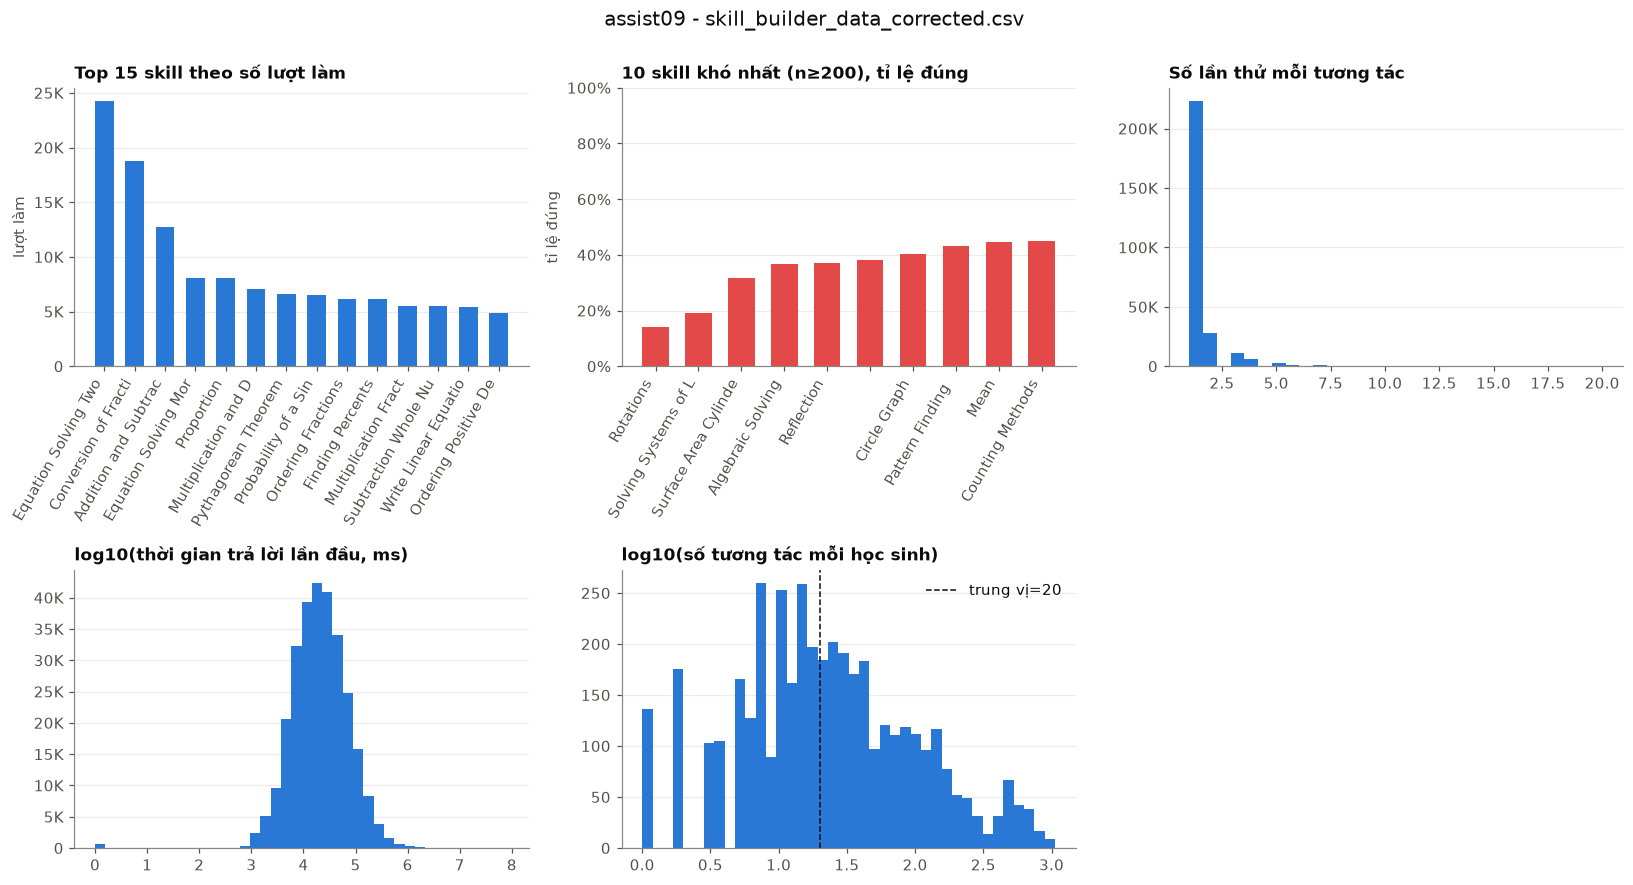

số lần thử trung vị/tương tác: 1.0 | có xin hint ở 15.0% tương tác


In [53]:
# hình gộp DUY NHẤT cho assist09: 2 hàng x 3 cột
skill_acc = (
    sb_valid.group_by("skill_id")
    .agg(pl.col("skill_name").first(), pl.len().alias("n"), pl.col("correct").mean().alias("acc"))
    .filter(pl.col("n") >= 200)
)
top_freq = sb_valid.group_by("skill_id").agg(pl.col("skill_name").first(), pl.len().alias("n")).sort("n", descending=True).head(15)
hardest = skill_acc.sort("acc").head(10)
seq_len09_np = seq_len09.to_numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
bar(axes[0,0], [s[:20] for s in top_freq["skill_name"].to_list()], top_freq["n"].to_list(),
    DATASET_COLORS["assist09"], "Top 15 skill theo số lượt làm", "lượt làm", rot=60)
bar(axes[0,1], [s[:20] for s in hardest["skill_name"].to_list()], hardest["acc"].to_list(),
    "#e34948", "10 skill khó nhất (n≥200), tỉ lệ đúng", "tỉ lệ đúng", rot=60, yfmt="pct")
axes[0,1].set_ylim(0, 1)

axes[0,2].hist(sb_int["attempt_count"].drop_nulls(), bins=30, color=DATASET_COLORS["assist09"], range=(1, 20))
axes[0,2].set_title("Số lần thử mỗi tương tác", loc="left"); style_ax(axes[0,2])

axes[1,0].hist(np.log10(sb_int["ms_first_response"].drop_nulls().to_numpy().clip(1, None)), bins=40, color=DATASET_COLORS["assist09"])
axes[1,0].set_title("log10(thời gian trả lời lần đầu, ms)", loc="left"); style_ax(axes[1,0])

axes[1,1].hist(np.log10(seq_len09_np), bins=40, color=DATASET_COLORS["assist09"])
axes[1,1].axvline(np.log10(np.median(seq_len09_np)), color=INK, ls="--", lw=1, label=f"trung vị={np.median(seq_len09_np):.0f}")
axes[1,1].legend(frameon=False)
axes[1,1].set_title("log10(số tương tác mỗi học sinh)", loc="left"); style_ax(axes[1,1])

off(axes[1,2])
fig.suptitle("assist09 - skill_builder_data_corrected.csv", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()
print(f"số lần thử trung vị/tương tác: {sb_int['attempt_count'].median()} | "
      f"có xin hint ở {(sb_int['hint_count']>0).mean():.1%} tương tác")


### 2.3 Cấu trúc file `assist12`

In [54]:
ASSIST12_ZIP = DATASETS_DIR / "dataset ASSISTments" / "2012-13-school-data-with-affect" / "full_data.csv"
ASSIST12_RAW = DATA_CACHE / "raw" / "assist12" / "2012-2013-data-with-predictions-4-final.csv"

print(f"full_data.csv thực chất là file ZIP ({_sz(ASSIST12_ZIP)}) chứa 1 CSV bên trong.")
if not ASSIST12_RAW.exists():
    ASSIST12_RAW.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ASSIST12_ZIP) as z:
        inner = z.namelist()[0]
        z.extract(inner, ASSIST12_RAW.parent)
        (ASSIST12_RAW.parent / inner).rename(ASSIST12_RAW)
print("đã giải nén ra:", ASSIST12_RAW, f"({_sz(ASSIST12_RAW)})")

_, cols12 = file_schema(ASSIST12_RAW, schema_overrides={"skill_id": pl.Utf8, "skill": pl.Utf8},
                          title="2012-2013-data-with-predictions-4-final.csv")


full_data.csv thực chất là file ZIP (550MB) chứa 1 CSV bên trong.
đã giải nén ra: /home/admincsc/workspace/binh/openscience_kt_workspace/code/data_cache/raw/assist12/2012-2013-data-with-predictions-4-final.csv (3GB)

[2012-2013-data-with-predictions-4-final.csv]  6,123,270 dòng x 35 cột  (3,009.5 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,problem_log_id,Int64,6123270,100.0%
1,skill,String,6123270,100.0%
2,problem_id,Int64,6123270,100.0%
3,user_id,Int64,6123270,100.0%
4,assignment_id,Int64,6123270,100.0%
5,assistment_id,Int64,6123270,100.0%
6,start_time,String,6123270,100.0%
7,end_time,String,6123270,100.0%
8,problem_type,String,6123270,100.0%
9,original,Int64,6123270,100.0%


Vài dòng dữ liệu mẫu:


problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,correct,bottom_hint,hint_count,actions,attempt_count,ms_first_response,tutor_mode,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,teacher_id,school_id,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
i64,str,i64,i64,i64,i64,str,str,str,i64,f64,str,i64,str,i64,i64,str,i64,i64,i64,str,i64,str,i64,i64,i64,i64,str,str,i64,i64,f64,f64,f64,f64
137792159,"""""",557460,61394,565736,341511,"""2012-09-28 15:11:27""","""2012-09-28 15:11:36.856""","""choose_1""",1,1.0,"""0""",0,"""--- - - start - 13488594875…",1,9852,"""tutor""",55482,23643,4,"""LinearSection""",55482,"""""",53472,5048,9852,341511,"""""","""she""",0,137792159,0.361323,0.0,0.336529,0.0
138083797,"""Rounding""",365981,61394,573819,204043,"""2012-10-09 11:01:52""","""2012-10-09 11:02:13.182""","""algebra""",1,1.0,"""0""",0,"""--- - - start - 13497949122…",1,21175,"""tutor""",34221,22967,5,"""LinearSection""",34221,"""54""",47424,5048,21175,204043,"""""","""74.29""",0,138083797,0.361323,0.0,0.766925,0.0
142332619,"""Multiplication and Division In…",426415,61394,734130,247525,"""2013-03-07 10:53:20""","""2013-03-07 10:53:28.661""","""algebra""",1,0.0,"""0""",0,"""--- - - start - 13626716004…",1,8645,"""tutor""",39601,22967,58,"""LinearSection""",39601,"""279""",47424,5048,8645,247525,"""""","""00""",0,142332619,0.361323,0.0,0.766925,0.442968


**Liên kết:** `assist12` là dataset độc lập với `assist09` (khác năm học,
`user_id`/`problem_id` không dùng chung namespace). Toàn bộ nằm trong **1
file duy nhất** - không cần join với file khác. Các cột
`Average_confidence(FRUSTRATED/CONFUSED/CONCENTRATING/BORED)` là **kết quả dự
đoán bằng mô hình** (không phải học sinh tự khai báo) gắn theo `problem_log_id`.


### 2.4 Phân tích & trực quan hóa `assist12`

In [55]:
AFFECT_COLS = ["Average_confidence(FRUSTRATED)", "Average_confidence(CONFUSED)",
               "Average_confidence(CONCENTRATING)", "Average_confidence(BORED)"]
lf12 = pl.scan_csv(ASSIST12_RAW, infer_schema_length=10000, ignore_errors=True,
                    schema_overrides={"skill_id": pl.Utf8, "skill": pl.Utf8})
sel = ["user_id", "problem_id", "skill_id", "skill", "correct", "problem_log_id",
       "hint_count", "attempt_count", "ms_first_response"] + AFFECT_COLS
df12 = lf12.select(sel).filter(
    pl.col("skill_id").is_not_null() & (pl.col("skill_id") != "") & pl.col("correct").is_in([0, 1])
).collect(engine="streaming")

n12 = df12.shape[0]
print(f"dòng thô: {lf12.select(pl.len()).collect().item():,} -> tương tác hợp lệ: {n12:,}")
print(f"học sinh: {df12['user_id'].n_unique():,} | bài toán: {df12['problem_id'].n_unique():,} | "
      f"skill: {df12['skill_id'].n_unique()} | tỉ lệ đúng: {df12['correct'].mean():.1%}")

seq_len12 = df12.group_by("user_id").len()["len"]
SUMMARY["assist12"] = dict(
    family="ASSISTments 12-13", n_interactions=n12, n_students=df12["user_id"].n_unique(),
    n_questions=df12["problem_id"].n_unique(), n_kcs=df12["skill_id"].n_unique(), pct_multi_kc=0.0,
    correct_rate=float(df12["correct"].mean()), median_seq_len=float(seq_len12.median()),
    has_timestamp=False, has_hint=True, has_affect=True, has_multimedia=False,
    file_format="CSV (nén zip), dấu phẩy", language="Tiếng Anh",
)


dòng thô: 6,123,270 -> tương tác hợp lệ: 2,711,602
học sinh: 29,018 | bài toán: 53,086 | skill: 265 | tỉ lệ đúng: 69.5%


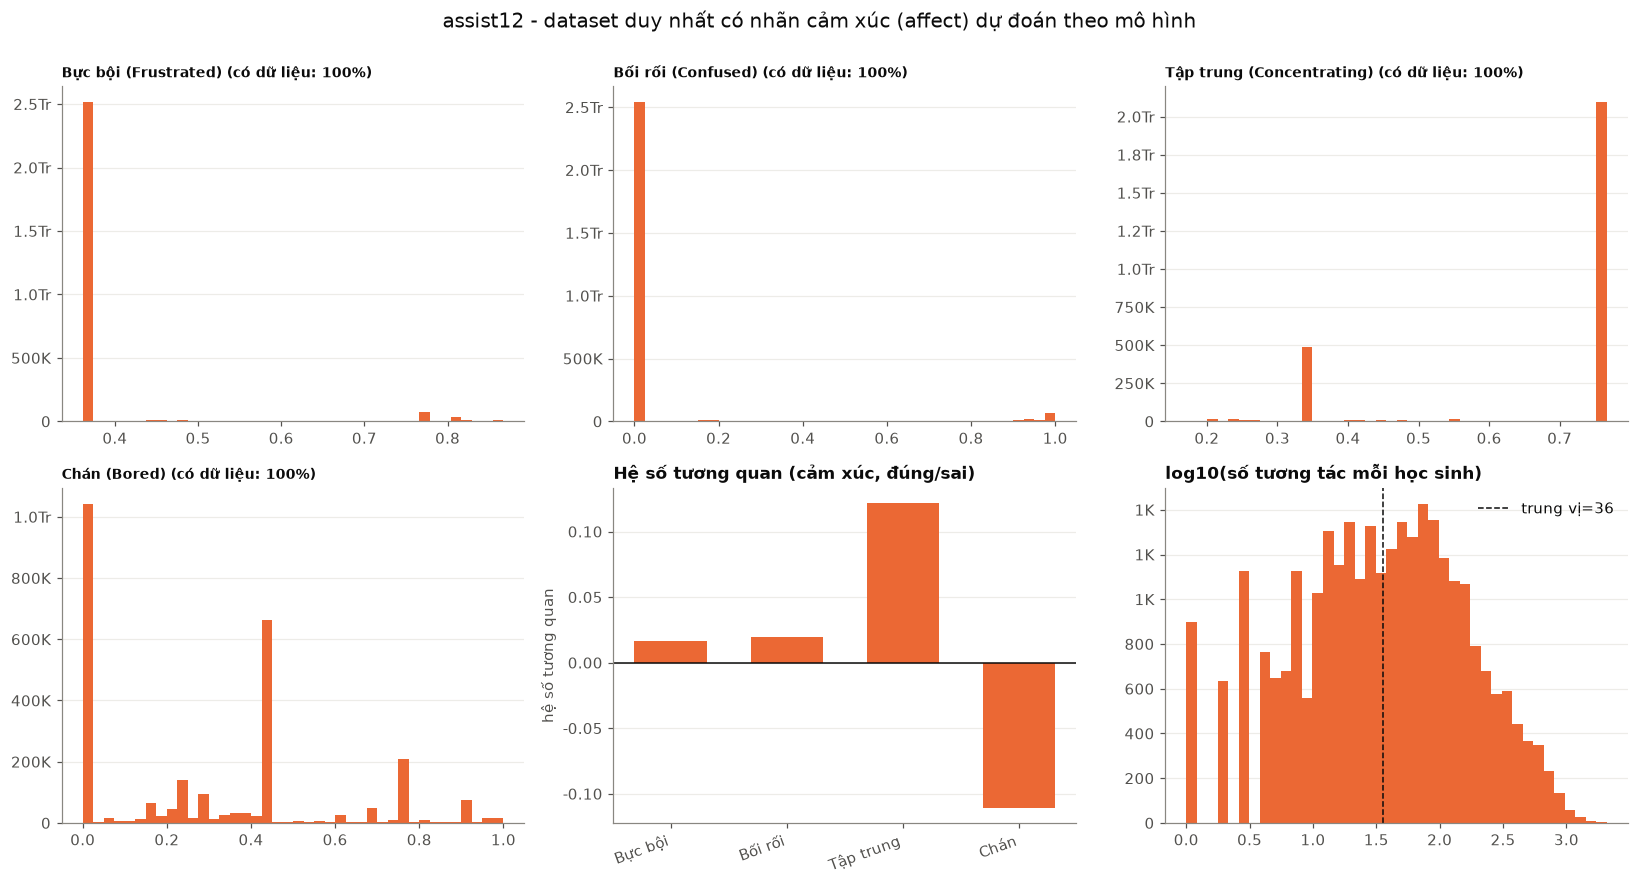

Tương quan mạnh nhất: Tập trung (+0.122). Tập trung tương quan thuận (+), Chán tương quan nghịch (-) với việc trả lời đúng - đúng kỳ vọng;
Bực bội và Bối rối lại chỉ tương quan rất yếu, gần như bằng 0 (+0.016 / +0.019) - trái với giả định thường gặp.


In [56]:
# hình gộp DUY NHẤT cho assist12: 2 hàng x 3 cột (4 affect + 1 tương quan + 1 độ dài chuỗi)
corrs = {}
for c in AFFECT_COLS:
    sub = df12.select(c, "correct").drop_nulls()
    corrs[c.split("(")[1][:-1]] = np.corrcoef(sub[c].to_numpy(), sub["correct"].to_numpy())[0, 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
labels_vn = {"FRUSTRATED": "Bực bội (Frustrated)", "CONFUSED": "Bối rối (Confused)",
             "CONCENTRATING": "Tập trung (Concentrating)", "BORED": "Chán (Bored)"}
for ax, c in zip(axes.flat[:4], AFFECT_COLS):
    key = c.split("(")[1][:-1]
    vals = df12[c].drop_nulls().to_numpy()
    ax.hist(vals, bins=40, color=DATASET_COLORS["assist12"])
    ax.set_title(f"{labels_vn[key]} (có dữ liệu: {len(vals)/n12:.0%})", loc="left", fontsize=9)
    style_ax(ax)

names = list(corrs.keys())
bar(axes[1,1], [labels_vn[k].split(" (")[0] for k in names], [corrs[k] for k in names],
    DATASET_COLORS["assist12"], "Hệ số tương quan (cảm xúc, đúng/sai)", "hệ số tương quan", yfmt="corr", rot=20)
axes[1,1].axhline(0, color=INK, lw=1)

seq_len12_np = seq_len12.to_numpy()
axes[1,2].hist(np.log10(seq_len12_np), bins=40, color=DATASET_COLORS["assist12"])
axes[1,2].axvline(np.log10(np.median(seq_len12_np)), color=INK, ls="--", lw=1, label=f"trung vị={np.median(seq_len12_np):.0f}")
axes[1,2].legend(frameon=False)
axes[1,2].set_title("log10(số tương tác mỗi học sinh)", loc="left"); style_ax(axes[1,2])

fig.suptitle("assist12 - dataset duy nhất có nhãn cảm xúc (affect) dự đoán theo mô hình", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()
strongest = max(corrs, key=lambda k: abs(corrs[k]))
print(f"Tương quan mạnh nhất: {labels_vn[strongest].split(' (')[0]} ({corrs[strongest]:+.3f}). "
      f"Tập trung tương quan thuận (+), Chán tương quan nghịch (-) với việc trả lời đúng - đúng kỳ vọng;\n"
      f"Bực bội và Bối rối lại chỉ tương quan rất yếu, gần như bằng 0 ({corrs['FRUSTRATED']:+.3f} / {corrs['CONFUSED']:+.3f}) - trái với giả định thường gặp.")


## 3. Eedi NeurIPS 2020 (task 1/2)

Khác biệt lớn nhất so với 2 family trên: KC không phải nhãn kỹ năng phẳng mà
là **cây môn học 4 cấp** (`SubjectId` → `ParentId` → ... → gốc "Maths"), mỗi
câu hỏi có thể gắn nhiều subject ở nhiều cấp cùng lúc. Có ảnh minh hoạ, độ
tuổi/giới tính học sinh, và một trường **tự đánh giá độ tự tin** hiếm gặp.


### 3.1 Cấu trúc file

In [57]:
display(inv[inv.family == "dataset Eedi NeurIPS 2020"].reset_index(drop=True))
n_eedi_images = len(list((DATASETS_DIR / "dataset Eedi NeurIPS 2020" / "data_extracted" / "data" / "images").glob("*.jpg")))
print(f"+ thư mục images/: {n_eedi_images} file .jpg (đặt tên theo QuestionId, ví dụ '{ (DATASETS_DIR / 'dataset Eedi NeurIPS 2020' / 'data_extracted' / 'data' / 'images').glob('*.jpg').__next__().name }')")


,family,file,kích thước
0,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/answer_metadata_t...,972MB
1,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/answer_metadata_t...,70MB
2,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/question_metadata...,724KB
3,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/question_metadata...,22KB
4,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/student_metadata_...,3MB
5,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/student_metadata_...,130KB
6,dataset Eedi NeurIPS 2020,data_extracted/data/metadata/subject_metadata.csv,13KB
7,dataset Eedi NeurIPS 2020,data_extracted/data/test_data/quality_response...,683B
8,dataset Eedi NeurIPS 2020,data_extracted/data/test_data/quality_response...,691B
9,dataset Eedi NeurIPS 2020,data_extracted/data/test_data/test_private_ans...,44MB


+ thư mục images/: 948 file .jpg (đặt tên theo QuestionId, ví dụ '580.jpg')


In [58]:
EEDI_DIR = DATASETS_DIR / "dataset Eedi NeurIPS 2020" / "data_extracted" / "data"

_, _ = file_schema(EEDI_DIR / "train_data" / "train_task_1_2.csv", title="train_task_1_2.csv - log tương tác chính")



[train_task_1_2.csv - log tương tác chính]  15,867,850 dòng x 6 cột  (430.0 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,QuestionId,Int64,15867850,100.0%
1,UserId,Int64,15867850,100.0%
2,AnswerId,Int64,15867850,100.0%
3,IsCorrect,Int64,15867850,100.0%
4,CorrectAnswer,Int64,15867850,100.0%
5,AnswerValue,Int64,15867850,100.0%


Vài dòng dữ liệu mẫu:


QuestionId,UserId,AnswerId,IsCorrect,CorrectAnswer,AnswerValue
i64,i64,i64,i64,i64,i64
16997,65967,12453206,0,4,2
16531,62121,15686710,1,1,1
15911,50013,13598796,0,3,1


In [59]:
_, _ = file_schema(EEDI_DIR / "metadata" / "question_metadata_task_1_2.csv", title="question_metadata_task_1_2.csv - danh sách SubjectId (KC) của mỗi câu hỏi")



[question_metadata_task_1_2.csv - danh sách SubjectId (KC) của mỗi câu hỏi]  27,613 dòng x 2 cột  (0.7 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,QuestionId,Int64,27613,100.0%
1,SubjectId,String,27613,100.0%


Vài dòng dữ liệu mẫu:


QuestionId,SubjectId
i64,str
13090,"""[3, 32, 71, 77, 141, 185, 186,…"
1855,"""[3, 71, 75, 86, 178]"""
10423,"""[3, 32, 38, 239]"""


In [60]:
_, _ = file_schema(EEDI_DIR / "metadata" / "subject_metadata.csv", title="subject_metadata.csv - cây phân cấp môn học (SubjectId -> ParentId)")



[subject_metadata.csv - cây phân cấp môn học (SubjectId -> ParentId)]  388 dòng x 4 cột  (0.0 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,SubjectId,Int64,388,100.0%
1,Name,String,388,100.0%
2,ParentId,String,388,100.0%
3,Level,Int64,388,100.0%


Vài dòng dữ liệu mẫu:


SubjectId,Name,ParentId,Level
i64,str,str,i64
3,"""Maths""","""NULL""",0
32,"""Number""","""3""",1
33,"""BIDMAS""","""144""",3


In [61]:
_, _ = file_schema(EEDI_DIR / "metadata" / "student_metadata_task_1_2.csv", title="student_metadata_task_1_2.csv - thông tin học sinh")



[student_metadata_task_1_2.csv - thông tin học sinh]  118,971 dòng x 4 cột  (3.3 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,UserId,Int64,118971,100.0%
1,Gender,Int64,118971,100.0%
2,DateOfBirth,String,80581,67.7%
3,PremiumPupil,Float64,34386,28.9%


Vài dòng dữ liệu mẫu:


UserId,Gender,DateOfBirth,PremiumPupil
i64,i64,str,f64
58022,2,"""2006-08-01 00:00:00.000""",1.0
104674,0,null,null
32020,2,"""2008-11-01 00:00:00.000""",1.0


In [62]:
_, _ = file_schema(EEDI_DIR / "metadata" / "answer_metadata_task_1_2.csv", title="answer_metadata_task_1_2.csv - thời điểm trả lời + độ tự tin")



[answer_metadata_task_1_2.csv - thời điểm trả lời + độ tự tin]  19,834,820 dòng x 6 cột  (1,019.4 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,AnswerId,Float64,19834813,100.0%
1,DateAnswered,String,19834820,100.0%
2,Confidence,Float64,1882692,9.5%
3,GroupId,Int64,19834820,100.0%
4,QuizId,Int64,19834820,100.0%
5,SchemeOfWorkId,Float64,9726880,49.0%


Vài dòng dữ liệu mẫu:


AnswerId,DateAnswered,Confidence,GroupId,QuizId,SchemeOfWorkId
f64,str,f64,i64,i64,f64
1.1808339e7,"""2020-03-17 07:55:00.000""",null,4186,14854,null
98649.0,"""2018-12-18 14:23:00.000""",null,9427,16895,28237.0
259238.0,"""2019-02-21 12:41:00.000""",null,7651,1127,8386.0


**Liên kết giữa các file:** `train_task_1_2.QuestionId` → nối với
`question_metadata_task_1_2.QuestionId` để lấy danh sách `SubjectId` (KC);
mỗi `SubjectId` lại nối tiếp vào `subject_metadata.SubjectId` (leo lên
`ParentId` để ra cả chuỗi tổ tiên tới gốc "Maths"). `train_task_1_2.UserId`
→ `student_metadata_task_1_2.UserId` (giới tính, ngày sinh, học sinh có được
trợ cấp - premium pupil). `train_task_1_2.AnswerId` → `answer_metadata_task_1_2.AnswerId`
(thời điểm trả lời, độ tự tin tự khai báo). Ảnh trong `images/{QuestionId}.jpg`
minh hoạ trực tiếp cho câu hỏi tương ứng. `*_task_3_4.csv` là một cặp
train/metadata riêng cho bài toán dự đoán khác (task 3/4), không dùng ở đây.


### 3.2 Phân tích & trực quan hóa

In [63]:
subj = pl.read_csv(EEDI_DIR / "metadata" / "subject_metadata.csv")
subj = subj.with_columns(pl.col("ParentId").cast(pl.Utf8, strict=False))
parent = {str(r["SubjectId"]): (None if r["ParentId"] == "NULL" else r["ParentId"]) for r in subj.iter_rows(named=True)}
name = {str(r["SubjectId"]): r["Name"] for r in subj.iter_rows(named=True)}
# 1 subject là "leaf" (kỹ năng chi tiết nhất) nếu không subject nào khác coi
# nó là ParentId - các id không-leaf trong SubjectId list chỉ là CHUỖI TỔ TIÊN
# lên tới "Maths", không phải kỹ năng độc lập thêm.
parents_used = set(subj["ParentId"].drop_nulls().to_list()) - {"NULL"}
is_leaf = {str(r["SubjectId"]): str(r["SubjectId"]) not in parents_used for r in subj.iter_rows(named=True)}

qmeta = pl.read_csv(EEDI_DIR / "metadata" / "question_metadata_task_1_2.csv")
q2kc = {int(r["QuestionId"]): [str(s) for s in ast.literal_eval(r["SubjectId"])] for r in qmeta.iter_rows(named=True)}
q2leaf = {q: [s for s in ids if is_leaf.get(s, False)] for q, ids in q2kc.items()}
n_kc_per_q = [len(v) for v in q2kc.values()]
n_leaf_per_q = [len(v) for v in q2leaf.values()]
print(f"subject trong cây phân cấp: {len(subj)} ở các cấp {sorted(subj['Level'].unique().to_list())}")
print(f"câu hỏi có gắn subject: {len(q2kc)} | độ dài chuỗi subject TB/câu hỏi: {np.mean(n_kc_per_q):.2f} "
      f"(gồm cả tổ tiên tới 'Maths', KHÔNG phải {len(q2kc)} kỹ năng độc lập)")
print(f"số kỹ năng LEAF (chi tiết nhất, so sánh được với KC ở dataset khác) TB/câu hỏi: "
      f"{np.mean(n_leaf_per_q):.2f} | tỉ lệ câu hỏi >1 leaf skill: {np.mean([n>1 for n in n_leaf_per_q]):.1%}")


subject trong cây phân cấp: 388 ở các cấp [0, 1, 2, 3]
câu hỏi có gắn subject: 27613 | độ dài chuỗi subject TB/câu hỏi: 4.17 (gồm cả tổ tiên tới 'Maths', KHÔNG phải 27613 kỹ năng độc lập)
số kỹ năng LEAF (chi tiết nhất, so sánh được với KC ở dataset khác) TB/câu hỏi: 1.11 | tỉ lệ câu hỏi >1 leaf skill: 8.9%


In [64]:
train = pl.scan_csv(EEDI_DIR / "train_data" / "train_task_1_2.csv").filter(
    pl.col("IsCorrect").is_in([0, 1])
).collect(engine="streaming")
n_eedi = train.shape[0]
n_users_eedi, n_q_eedi = train["UserId"].n_unique(), train["QuestionId"].n_unique()
n_kc_eedi = sum(is_leaf.values())
print(f"tương tác: {n_eedi:,} | học sinh: {n_users_eedi:,} | câu hỏi: {n_q_eedi:,} | "
      f"leaf skill: {n_kc_eedi} | tỉ lệ đúng: {train['IsCorrect'].mean():.1%}")

pct_multi_eedi = np.mean([len(q2leaf.get(q, [])) > 1 for q in train["QuestionId"].unique().to_list()])
seq_len_eedi = train.group_by("UserId").len()["len"]
SUMMARY["eedi"] = dict(
    family="Eedi NeurIPS'20", n_interactions=n_eedi, n_students=n_users_eedi, n_questions=n_q_eedi,
    n_kcs=n_kc_eedi, pct_multi_kc=float(pct_multi_eedi), correct_rate=float(train["IsCorrect"].mean()),
    median_seq_len=float(seq_len_eedi.median()), has_timestamp=False, has_hint=False, has_affect=False,
    has_multimedia=True, file_format="CSV, dấu phẩy", language="Tiếng Anh",
)

smeta = pl.read_csv(EEDI_DIR / "metadata" / "student_metadata_task_1_2.csv", try_parse_dates=False)
smeta = smeta.with_columns(pl.col("DateOfBirth").str.slice(0, 4).cast(pl.Int64, strict=False).alias("birth_year"))
ans = pl.scan_csv(EEDI_DIR / "metadata" / "answer_metadata_task_1_2.csv").select("Confidence").collect(engine="streaming")
conf = ans["Confidence"].drop_nulls().to_numpy()
print(f"độ tự tin (Confidence) chỉ có ở {len(conf)/len(ans):.1%} lượt trả lời")


tương tác: 15,867,850 | học sinh: 118,971 | câu hỏi: 27,613 | leaf skill: 316 | tỉ lệ đúng: 64.3%
độ tự tin (Confidence) chỉ có ở 9.5% lượt trả lời


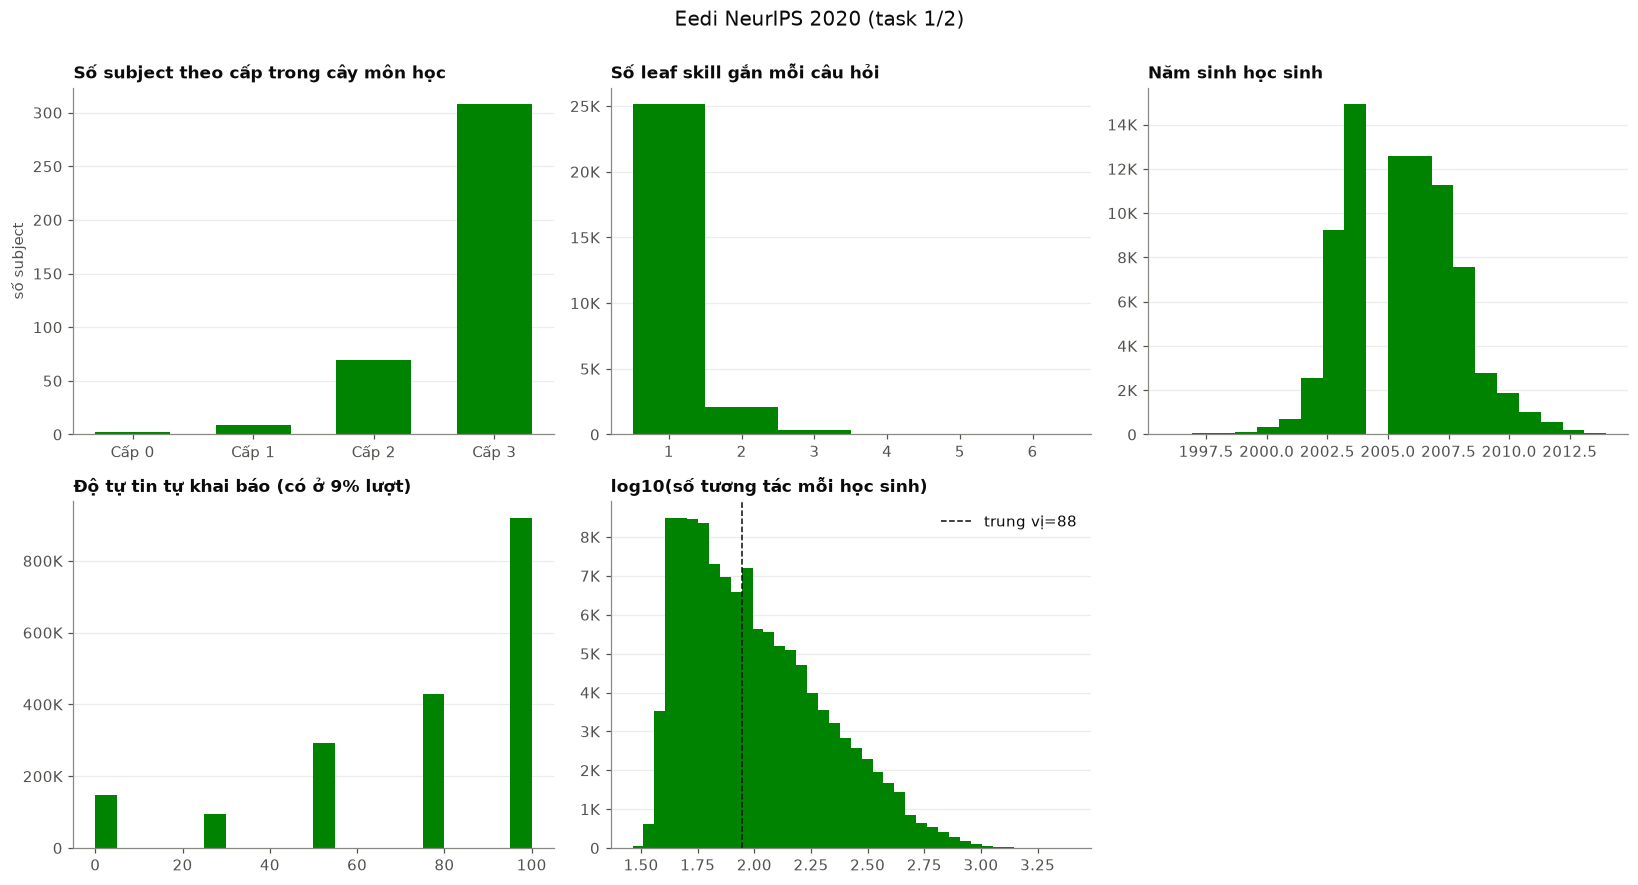

In [65]:
# hình gộp DUY NHẤT cho eedi: 2 hàng x 3 cột
lvl_counts = subj.group_by("Level").len().sort("Level")
by = smeta["birth_year"].drop_nulls().to_numpy()
seq_len_eedi_np = seq_len_eedi.to_numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
bar(axes[0,0], [f"Cấp {l}" for l in lvl_counts["Level"].to_list()], lvl_counts["len"].to_list(),
    DATASET_COLORS["eedi"], "Số subject theo cấp trong cây môn học", "số subject")
axes[0,1].hist(n_leaf_per_q, bins=range(1, max(n_leaf_per_q) + 2), color=DATASET_COLORS["eedi"], align="left")
axes[0,1].set_title("Số leaf skill gắn mỗi câu hỏi", loc="left"); style_ax(axes[0,1])
axes[0,2].hist(by[(by > 1995) & (by < 2015)], bins=20, color=DATASET_COLORS["eedi"])
axes[0,2].set_title("Năm sinh học sinh", loc="left"); style_ax(axes[0,2])

axes[1,0].hist(conf, bins=20, color=DATASET_COLORS["eedi"])
axes[1,0].set_title(f"Độ tự tin tự khai báo (có ở {len(conf)/len(ans):.0%} lượt)", loc="left"); style_ax(axes[1,0])

axes[1,1].hist(np.log10(seq_len_eedi_np), bins=40, color=DATASET_COLORS["eedi"])
axes[1,1].axvline(np.log10(np.median(seq_len_eedi_np)), color=INK, ls="--", lw=1, label=f"trung vị={np.median(seq_len_eedi_np):.0f}")
axes[1,1].legend(frameon=False)
axes[1,1].set_title("log10(số tương tác mỗi học sinh)", loc="left"); style_ax(axes[1,1])
off(axes[1,2])

fig.suptitle("Eedi NeurIPS 2020 (task 1/2)", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()


## 4. Junyi Academy

Điểm khác biệt cấu trúc: mỗi dòng log có cờ **is_downgrade / is_upgrade**
(hệ thống tự điều chỉnh độ khó theo mastery) và
**exercise_problem_repeat_session** (số lần học sinh luyện lại *cùng* một
exercise) - hai tín hiệu thích ứng (adaptive) không xuất hiện ở family khác.


### 4.1 Cấu trúc file

In [66]:
display(inv[inv.family == "dataset Junyi Academy"].reset_index(drop=True))


,family,file,kích thước
0,dataset Junyi Academy,Junyi/Info_Content.csv,380KB
1,dataset Junyi Academy,Junyi/Info_UserData.csv,6MB
2,dataset Junyi Academy,Junyi/Log_Problem.csv,3GB


In [67]:
JUNYI_DIR = DATASETS_DIR / "dataset Junyi Academy" / "Junyi"

_, _ = file_schema(JUNYI_DIR / "Log_Problem.csv", title="Log_Problem.csv - log luyện tập chính")



[Log_Problem.csv - log luyện tập chính]  16,217,311 dòng x 14 cột  (3,020.8 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,timestamp_TW,String,16217311,100.0%
1,uuid,String,16217311,100.0%
2,ucid,String,16217311,100.0%
3,upid,String,16217311,100.0%
4,problem_number,Int64,16217311,100.0%
5,exercise_problem_repeat_session,Int64,16217311,100.0%
6,is_correct,Boolean,16217311,100.0%
7,total_sec_taken,Int64,16217311,100.0%
8,total_attempt_cnt,Int64,16217311,100.0%
9,used_hint_cnt,Int64,16217311,100.0%


Vài dòng dữ liệu mẫu:


timestamp_TW,uuid,ucid,upid,problem_number,exercise_problem_repeat_session,is_correct,total_sec_taken,total_attempt_cnt,used_hint_cnt,is_hint_used,is_downgrade,is_upgrade,level
str,str,str,str,i64,i64,bool,i64,i64,i64,bool,bool,bool,i64
"""2019-05-26 21:00:00 UTC""","""FLy+lviglNR5Y1l0Xiijnl6QHySBcp…","""KDOmuTrY/IJzDP4kIgIYCBiGyTymsJ…","""Vbs92l4JmdiWkUEm/iahxnUTaac2oN…",18,2,true,33,1,0,false,false,true,3
"""2019-05-17 16:30:00 UTC""","""+Gqj2nalc6M9fusyVECTC0AN7UQdDQ…","""COZ39Wo+uIUO2s7c2VGEHjJf6Vx0xi…","""Ek+pIeHNNoEo0tGEq91eBcBmGgy3+A…",4,1,true,8,1,0,false,null,null,0
"""2019-05-15 19:15:00 UTC""","""6D5QN8j8ng/VR74ES3A0zqAj0bIFFy…","""TwyqyV1uJYlDAX8wX/PtTCVZEBo/AP…","""1MBa2f5Qog4JBoAuUfJf0fxeJctdEi…",9,1,true,17,1,0,false,null,null,0


In [68]:
_, _ = file_schema(JUNYI_DIR / "Info_UserData.csv", title="Info_UserData.csv - hồ sơ học sinh")



[Info_UserData.csv - hồ sơ học sinh]  72,758 dòng x 12 cột  (6.4 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,uuid,String,72758,100.0%
1,gender,String,32905,45.2%
2,points,Int64,72758,100.0%
3,badges_cnt,Int64,72758,100.0%
4,first_login_date_TW,String,72758,100.0%
5,user_grade,Int64,72758,100.0%
6,user_city,String,72758,100.0%
7,has_teacher_cnt,Int64,72758,100.0%
8,is_self_coach,Boolean,72758,100.0%
9,has_student_cnt,Int64,72758,100.0%


Vài dòng dữ liệu mẫu:


uuid,gender,points,badges_cnt,first_login_date_TW,user_grade,user_city,has_teacher_cnt,is_self_coach,has_student_cnt,belongs_to_class_cnt,has_class_cnt
str,str,i64,i64,str,i64,str,i64,bool,i64,i64,i64
"""Y2RcCdmUJAYPUAIDElo4nE9KrkLLFz…",null,18300,1,"""2019-01-24""",1,"""kh""",0,false,0,0,0
"""lw/Rchfvl9q1UDaQRmeE6QJDJeXAK7…",null,6468,0,"""2019-01-24""",1,"""ntpc""",1,false,0,1,0
"""ncVYyCw3osV77X9M+4NbI7LvBR5UiB…","""male""",4703,0,"""2019-01-24""",1,"""tp""",0,false,0,0,0


In [69]:
_, _ = file_schema(JUNYI_DIR / "Info_Content.csv", title="Info_Content.csv - metadata bài luyện tập (KC)")



[Info_Content.csv - metadata bài luyện tập (KC)]  1,330 dòng x 10 cột  (0.4 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,ucid,String,1330,100.0%
1,content_pretty_name,String,1330,100.0%
2,content_kind,String,1330,100.0%
3,difficulty,String,1330,100.0%
4,subject,String,1330,100.0%
5,learning_stage,String,1330,100.0%
6,level1_id,String,1330,100.0%
7,level2_id,String,1330,100.0%
8,level3_id,String,1330,100.0%
9,level4_id,String,1330,100.0%


Vài dòng dữ liệu mẫu:


ucid,content_pretty_name,content_kind,difficulty,subject,learning_stage,level1_id,level2_id,level3_id,level4_id
str,str,str,str,str,str,str,str,str,str
"""odIwFdIiecFwVUAEEV40K3MSuCSlIZ…","""【基礎】怎樣解題：數量關係""","""Exercise""","""easy""","""math""","""elementary""","""aH0Dz0KdH9gio7rrcGRHvrmd9vcd/0…","""ICgke8JJv5eapCPwyj1aco8PEtoBkU…","""bo3jsx1beVLEZ+2sckxdZNYnlLpVS7…","""KPJMQebU0O24+NzlQ4udb2BXLlKV1H…"
"""dfeeBaa8zDhWS6nu7zeXKwLyi4zqEa…","""【基礎】和差問題 1""","""Exercise""","""easy""","""math""","""elementary""","""aH0Dz0KdH9gio7rrcGRHvrmd9vcd/0…","""ICgke8JJv5eapCPwyj1aco8PEtoBkU…","""bo3jsx1beVLEZ+2sckxdZNYnlLpVS7…","""KPJMQebU0O24+NzlQ4udb2BXLlKV1H…"
"""C2AT0OBTUn+PRxEVd39enhW/DJtka1…","""【基礎】雞兔問題 1""","""Exercise""","""easy""","""math""","""elementary""","""aH0Dz0KdH9gio7rrcGRHvrmd9vcd/0…","""ICgke8JJv5eapCPwyj1aco8PEtoBkU…","""bo3jsx1beVLEZ+2sckxdZNYnlLpVS7…","""KPJMQebU0O24+NzlQ4udb2BXLlKV1H…"


**Liên kết:** `Log_Problem.uuid` → `Info_UserData.uuid` (hồ sơ học sinh:
điểm, huy hiệu, khối lớp); `Log_Problem.ucid` → `Info_Content.ucid` (tên bài,
độ khó, vị trí trong cây kiến thức `level1_id`…`level4_id`). `upid` (mã bài
tập cụ thể trong 1 exercise) **không có file metadata riêng** - chỉ `ucid`
(exercise) mới có mô tả nội dung.


### 4.2 Phân tích & trực quan hóa

In [70]:
content = pl.read_csv(JUNYI_DIR / "Info_Content.csv", ignore_errors=True)
users = pl.read_csv(JUNYI_DIR / "Info_UserData.csv", ignore_errors=True)
print(f"bài luyện tập (KC): {content.shape[0]} | học sinh đăng ký: {users.shape[0]:,}")
print("mức độ khó:", dict(zip(*content["difficulty"].value_counts().to_dict().values())))

lf_log = pl.scan_csv(
    JUNYI_DIR / "Log_Problem.csv", infer_schema_length=10000, ignore_errors=True,
    schema_overrides={"is_correct": pl.Utf8, "uuid": pl.Utf8, "ucid": pl.Utf8, "upid": pl.Utf8},
).select(["uuid", "upid", "ucid", "is_correct", "total_sec_taken", "total_attempt_cnt",
          "used_hint_cnt", "is_hint_used", "is_downgrade", "is_upgrade",
          "exercise_problem_repeat_session", "level"]).filter(
    pl.col("is_correct").is_in(["True", "False"])
).with_columns((pl.col("is_correct") == "True").cast(pl.Int8).alias("correct"))
log = lf_log.collect(engine="streaming")
n_junyi = log.shape[0]
print(f"tương tác: {n_junyi:,} | học sinh: {log['uuid'].n_unique():,} | "
      f"bài tập: {log['upid'].n_unique():,} | KC (ucid): {log['ucid'].n_unique():,} | "
      f"tỉ lệ đúng: {log['correct'].mean():.1%}")
print(f"có xin hint ở {log['is_hint_used'].mean():.1%} lượt làm | "
      f"bị hạ độ khó {log['is_downgrade'].mean():.1%} / tăng độ khó {log['is_upgrade'].mean():.1%} thời gian")

seq_len_junyi = log.group_by("uuid").len()["len"]
SUMMARY["junyi"] = dict(
    family="Junyi Academy", n_interactions=n_junyi, n_students=log["uuid"].n_unique(),
    n_questions=log["upid"].n_unique(), n_kcs=log["ucid"].n_unique(), pct_multi_kc=0.0,
    correct_rate=float(log["correct"].mean()), median_seq_len=float(seq_len_junyi.median()),
    has_timestamp=True, has_hint=True, has_affect=False, has_multimedia=False,
    file_format="CSV, dấu phẩy", language="Tiếng Trung (nội dung) / id ẩn danh (log)",
)


bài luyện tập (KC): 1330 | học sinh đăng ký: 72,758
mức độ khó: {'normal': 305, 'easy': 835, 'unset': 41, 'hard': 149}
tương tác: 16,217,311 | học sinh: 72,758 | bài tập: 25,785 | KC (ucid): 1,326 | tỉ lệ đúng: 70.4%
có xin hint ở 22.8% lượt làm | bị hạ độ khó 1.3% / tăng độ khó 98.7% thời gian


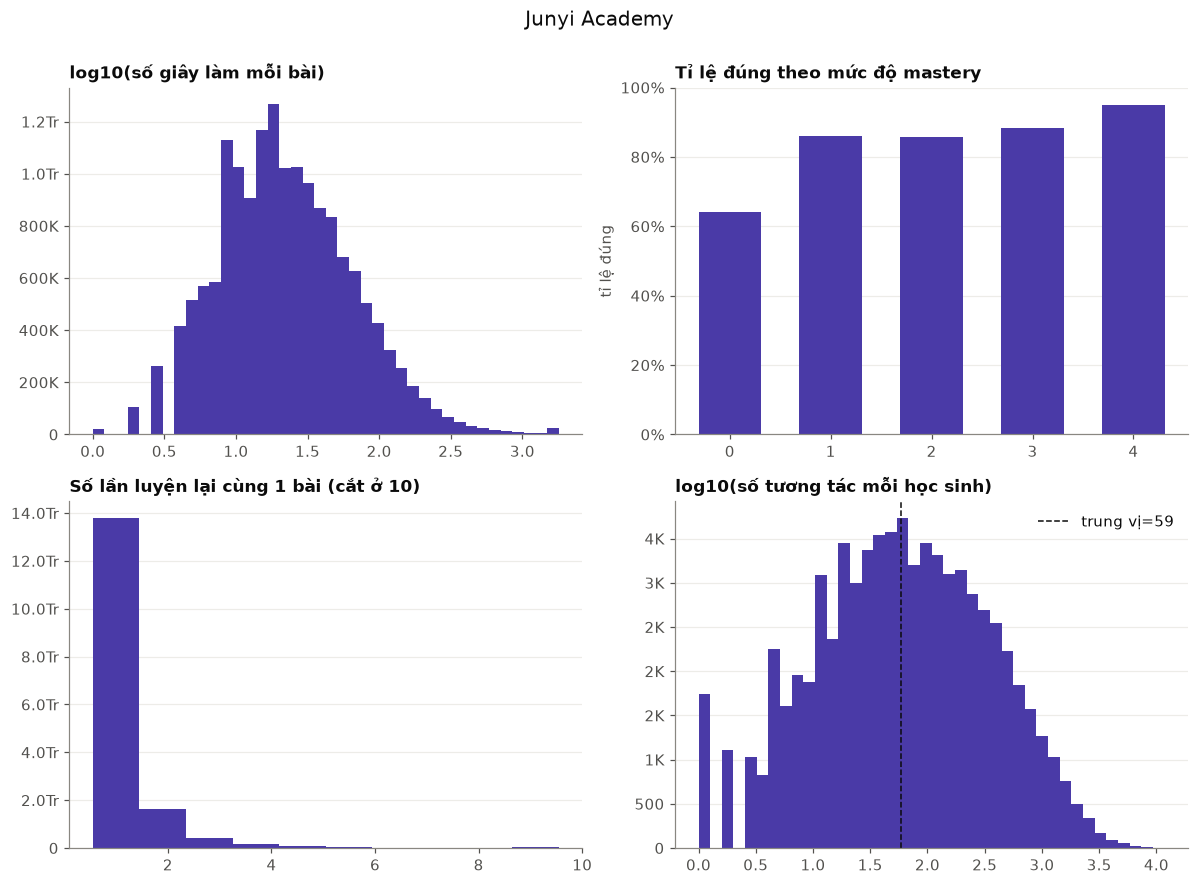

In [71]:
# hình gộp DUY NHẤT cho junyi: 2 hàng x 2 cột
sec = log["total_sec_taken"].drop_nulls().to_numpy()
sec = sec[(sec > 0) & (sec < 3600)]
by_level = log.group_by("level").agg(pl.col("correct").mean().alias("acc")).sort("level")
rep = log["exercise_problem_repeat_session"].drop_nulls().to_numpy()
seq_len_junyi_np = seq_len_junyi.to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].hist(np.log10(sec), bins=40, color=DATASET_COLORS["junyi"])
axes[0,0].set_title("log10(số giây làm mỗi bài)", loc="left"); style_ax(axes[0,0])

bar(axes[0,1], by_level["level"].to_list(), by_level["acc"].to_list(), DATASET_COLORS["junyi"],
    "Tỉ lệ đúng theo mức độ mastery", "tỉ lệ đúng", yfmt="pct")
axes[0,1].set_ylim(0, 1)

axes[1,0].hist(rep.clip(1, 10), bins=10, color=DATASET_COLORS["junyi"], align="left")
axes[1,0].set_title("Số lần luyện lại cùng 1 bài (cắt ở 10)", loc="left"); style_ax(axes[1,0])

axes[1,1].hist(np.log10(seq_len_junyi_np), bins=40, color=DATASET_COLORS["junyi"])
axes[1,1].axvline(np.log10(np.median(seq_len_junyi_np)), color=INK, ls="--", lw=1, label=f"trung vị={np.median(seq_len_junyi_np):.0f}")
axes[1,1].legend(frameon=False)
axes[1,1].set_title("log10(số tương tác mỗi học sinh)", loc="left"); style_ax(axes[1,1])

fig.suptitle("Junyi Academy", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()


## 5. PSLC KDD Cup 2010 (`algebra05`, `bridge06`)

Định dạng **tab-separated**, đơn vị KT là *step* (không phải problem):
`Problem Name` + `Step Name`. KC đến từ cột `KC(Default)`/`KC(SubSkills)`,
nhiều KC nối bằng `~~`. Mỗi thư mục có 4 file cùng schema nhưng vai trò khác
nhau - `_train.txt` có nhãn đầy đủ và là file duy nhất dùng để phân tích bên
dưới; `_test.txt` (đề thi KDD Cup gốc) ẩn nhãn `Correct First Attempt`;
`_master.txt` là đáp án đầy đủ của `_test.txt` (nối qua `Row`); file `.txt`
không có hậu tố chỉ chứa `Row` + `Correct First Attempt` - form nộp bài mẫu
của cuộc thi. `algebra05` và `bridge06` là 2 dataset (config) riêng biệt, mỗi
cái có 1 hình phân tích riêng.


### 5.1 Cấu trúc file

In [72]:
display(inv[inv.family == "dataset PSLC KDD Cup 2010"].reset_index(drop=True))


,family,file,kích thước
0,dataset PSLC KDD Cup 2010,algebra_2005_2006/algebra_2005_2006.txt,31KB
1,dataset PSLC KDD Cup 2010,algebra_2005_2006/algebra_2005_2006_master.txt,1MB
2,dataset PSLC KDD Cup 2010,algebra_2005_2006/algebra_2005_2006_test.txt,720KB
3,dataset PSLC KDD Cup 2010,algebra_2005_2006/algebra_2005_2006_train.txt,216MB
4,dataset PSLC KDD Cup 2010,bridge_to_algebra_2006_2007/bridge_to_algebra_...,66KB
5,dataset PSLC KDD Cup 2010,bridge_to_algebra_2006_2007/bridge_to_algebra_...,2MB
6,dataset PSLC KDD Cup 2010,bridge_to_algebra_2006_2007/bridge_to_algebra_...,1MB
7,dataset PSLC KDD Cup 2010,bridge_to_algebra_2006_2007/bridge_to_algebra_...,782MB


In [73]:
KDD_DIR = DATASETS_DIR / "dataset PSLC KDD Cup 2010"
_, _ = file_schema(KDD_DIR / "algebra_2005_2006" / "algebra_2005_2006_train.txt", sep="\t",
                    schema_overrides={"Correct First Attempt": pl.Int64, "Step Duration (sec)": pl.Float64},
                    title="algebra_2005_2006_train.txt")



[algebra_2005_2006_train.txt]  809,694 dòng x 19 cột  (226.7 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,Row,Int64,809694,100.0%
1,Anon Student Id,String,809694,100.0%
2,Problem Hierarchy,String,809694,100.0%
3,Problem Name,String,809694,100.0%
4,Problem View,Int64,809694,100.0%
5,Step Name,String,809694,100.0%
6,Step Start Time,String,808775,99.9%
7,First Transaction Time,String,809694,100.0%
8,Correct Transaction Time,String,783843,96.8%
9,Step End Time,String,809694,100.0%


Vài dòng dữ liệu mẫu:


Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
i64,str,str,str,i64,str,str,str,str,str,f64,f64,f64,i64,i64,i64,i64,str,str
1,"""0BrbPbwCMz""","""Unit ES_04, Section ES_04-1""","""EG4-FIXED""",1,"""3(x+2) = 15""","""2005-09-09 12:24:35.0""","""2005-09-09 12:24:49.0""","""2005-09-09 12:25:15.0""","""2005-09-09 12:25:15.0""",40.0,null,40.0,0,2,3,1,"""[SkillRule: Eliminate Parens; …","""1"""
2,"""0BrbPbwCMz""","""Unit ES_04, Section ES_04-1""","""EG4-FIXED""",1,"""x+2 = 5""","""2005-09-09 12:25:15.0""","""2005-09-09 12:25:31.0""","""2005-09-09 12:25:31.0""","""2005-09-09 12:25:31.0""",16.0,16.0,null,1,0,0,1,"""[SkillRule: Remove constant; {…","""1~~1"""
3,"""0BrbPbwCMz""","""Unit ES_04, Section ES_04-1""","""EG40""",1,"""2-8y = -4""","""2005-09-09 12:25:36.0""","""2005-09-09 12:25:43.0""","""2005-09-09 12:26:12.0""","""2005-09-09 12:26:12.0""",36.0,null,36.0,0,2,3,1,"""[SkillRule: Remove constant; {…","""2"""


In [74]:
_, _ = file_schema(KDD_DIR / "bridge_to_algebra_2006_2007" / "bridge_to_algebra_2006_2007_train.txt", sep="\t",
                    schema_overrides={"Correct First Attempt": pl.Int64, "Step Duration (sec)": pl.Float64},
                    title="bridge_to_algebra_2006_2007_train.txt")



[bridge_to_algebra_2006_2007_train.txt]  3,679,199 dòng x 19 cột  (819.9 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,Row,Int64,3679199,100.0%
1,Anon Student Id,String,3679199,100.0%
2,Problem Hierarchy,String,3679199,100.0%
3,Problem Name,String,3679199,100.0%
4,Problem View,Int64,3679199,100.0%
5,Step Name,String,3679199,100.0%
6,Step Start Time,String,3678572,100.0%
7,First Transaction Time,String,3679199,100.0%
8,Correct Transaction Time,String,3626286,98.6%
9,Step End Time,String,3679199,100.0%


Vài dòng dữ liệu mẫu:


Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(SubSkills),Opportunity(SubSkills)
i64,str,str,str,i64,str,str,str,str,str,f64,f64,f64,i64,i64,i64,i64,str,i64
1,"""2719gmbyqtjd""","""Unit PICTURE-ALGEBRA-1, Sectio…","""PICTALG3MU003""",1,"""InitialQuestion""","""2006-10-05 13:22:59.0""","""2006-10-05 13:24:33.0""","""2006-10-05 13:24:44.0""","""2006-10-05 13:24:44.0""",97.667,null,97.667,0,1,0,1,"""Identify larger quantity -- mu…",1
2,"""2719gmbyqtjd""","""Unit PICTURE-ALGEBRA-1, Sectio…","""PICTALG3MU003""",1,"""Label:1""","""2006-10-05 13:24:33.0""","""2006-10-05 13:24:44.0""","""2006-10-05 13:24:44.0""","""2006-10-05 13:24:44.0""",3.667,3.667,null,1,0,0,1,null,null
3,"""2719gmbyqtjd""","""Unit PICTURE-ALGEBRA-1, Sectio…","""PICTALG3MU003""",1,"""Label:2""","""2006-10-05 13:24:33.0""","""2006-10-05 13:24:44.0""","""2006-10-05 13:24:44.0""","""2006-10-05 13:24:44.0""",3.667,3.667,null,1,0,0,1,null,null


### 5.2 Phân tích & trực quan hóa

In [75]:
# Đọc 1 file *_train.txt của PSLC KDD Cup (algebra05 hoặc bridge06), chỉ giữ
# các cột cần cho phân tích, rồi lọc lại các dòng có KC hợp lệ và có nhãn
# Correct First Attempt (0/1) - dùng chung cho cả 2 config vì cùng schema.
def load_kdd(train_txt: Path, kc_col: str) -> pl.DataFrame:
    df = pl.read_csv(
        train_txt, separator="\t",
        columns=["Row", "Anon Student Id", "Problem Hierarchy", "Problem Name", "Step Name",
                 "Correct First Attempt", "Incorrects", "Hints", "Corrects",
                 "Step Duration (sec)", kc_col],
        schema_overrides={"Correct First Attempt": pl.Int64, "Step Duration (sec)": pl.Float64},
        ignore_errors=True,
    )
    return df.filter(pl.col(kc_col).is_not_null() & (pl.col(kc_col) != "") & pl.col("Correct First Attempt").is_in([0, 1]))

alg = load_kdd(KDD_DIR / "algebra_2005_2006" / "algebra_2005_2006_train.txt", "KC(Default)")
brg = load_kdd(KDD_DIR / "bridge_to_algebra_2006_2007" / "bridge_to_algebra_2006_2007_train.txt", "KC(SubSkills)")

# Tính và in các số liệu tổng hợp (số step, học sinh, bài toán, KC, tỉ lệ
# đa-KC, tỉ lệ đúng ngay lần đầu) cho 1 dataset PSLC, đồng thời ghi vào
# SUMMARY để dùng ở phần so sánh chéo (mục 7).
def kdd_stats(df: pl.DataFrame, kc_col: str, key: str):
    kcs = df[kc_col].str.split("~~")
    n_kc_per_step = kcs.list.len()
    all_kcs = kcs.explode().n_unique()
    units = df["Problem Hierarchy"].str.split(",").list.first().n_unique()
    seq_len = df.group_by("Anon Student Id").len()["len"]
    print(f"[{key}] step: {df.shape[0]:,} | học sinh: {df['Anon Student Id'].n_unique():,} | "
          f"bài toán: {df['Problem Name'].n_unique():,} | KC: {all_kcs} | "
          f"đơn vị chương trình học: {units} | step đa-KC: {(n_kc_per_step>1).mean():.1%} | "
          f"tỉ lệ đúng ngay lần đầu (CFA): {df['Correct First Attempt'].mean():.1%}")
    SUMMARY[key] = dict(
        family="PSLC KDD Cup", n_interactions=df.shape[0], n_students=df["Anon Student Id"].n_unique(),
        n_questions=df["Problem Name"].n_unique(), n_kcs=all_kcs, pct_multi_kc=float((n_kc_per_step > 1).mean()),
        correct_rate=float(df["Correct First Attempt"].mean()), median_seq_len=float(seq_len.median()),
        has_timestamp=True, has_hint=True, has_affect=False, has_multimedia=False,
        file_format="TXT, tab-separated", language="Tiếng Anh",
    )
    return n_kc_per_step, seq_len

nkc_alg, seq_len_alg = kdd_stats(alg, "KC(Default)", "algebra05")
nkc_brg, seq_len_brg = kdd_stats(brg, "KC(SubSkills)", "bridge06")


[algebra05] step: 607,025 | học sinh: 574 | bài toán: 1,084 | KC: 112 | đơn vị chương trình học: 32 | step đa-KC: 31.4% | tỉ lệ đúng ngay lần đầu (CFA): 75.5%
[bridge06] step: 1,817,476 | học sinh: 1,146 | bài toán: 19,005 | KC: 493 | đơn vị chương trình học: 36 | step đa-KC: 0.4% | tỉ lệ đúng ngay lần đầu (CFA): 83.2%


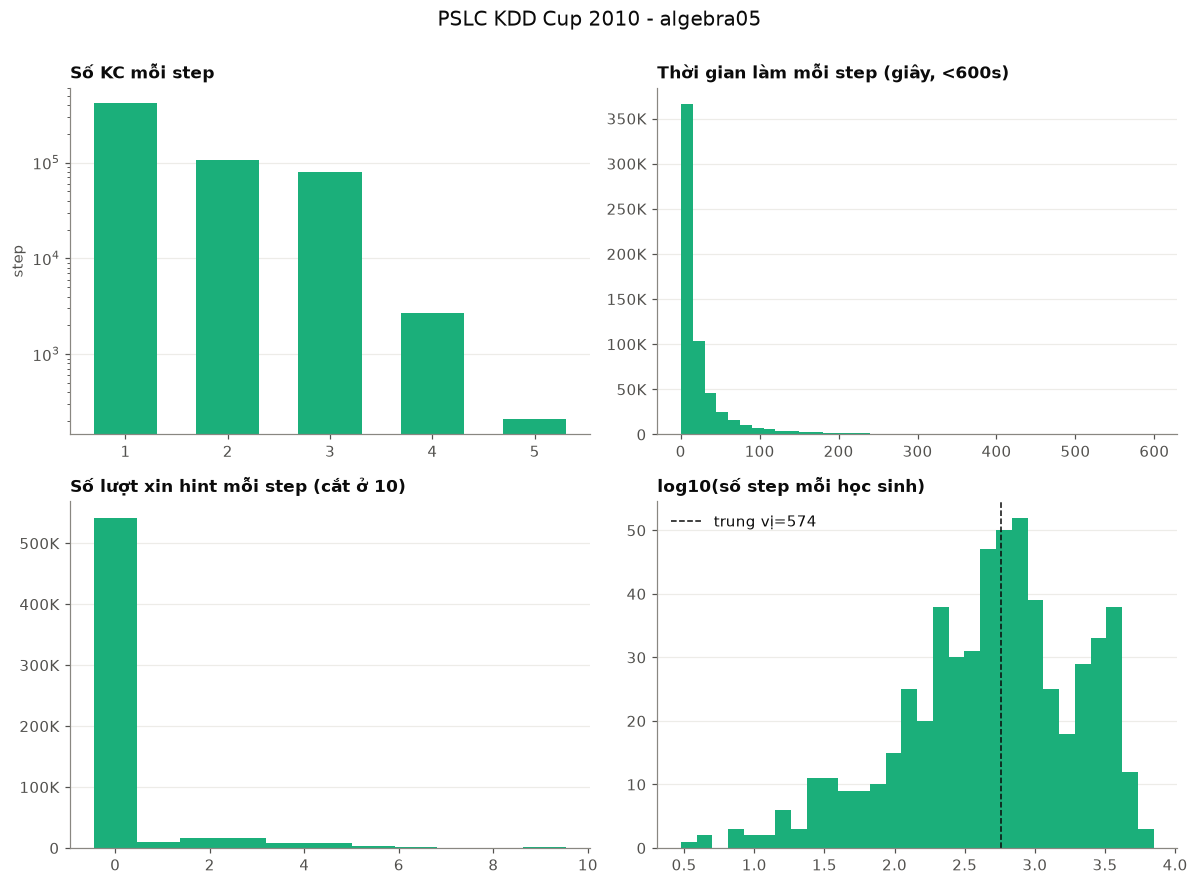

In [76]:
# Vẽ hình gộp DUY NHẤT (lưới 2x2: số KC/step, thời gian làm step, số lượt
# hint, độ dài chuỗi) cho 1 dataset PSLC - gọi lại 2 lần cho algebra05 và
# bridge06 vì cùng schema, chỉ khác màu/tên.
def plot_kdd_dataset(df, nkc, seq_len, key, hints_col="Hints", dur_col="Step Duration (sec)"):
    "Hình gộp DUY NHẤT cho 1 dataset PSLC (algebra05 hoặc bridge06): 2x2."
    color = DATASET_COLORS[key]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    counts = np.bincount(nkc.to_numpy())[1:6]
    bar(axes[0,0], [str(i) for i in range(1, len(counts)+1)], counts, color,
        "Số KC mỗi step", "step", ylog=True)

    dur = df[dur_col].drop_nulls().to_numpy()
    dur = dur[(dur > 0) & (dur < 600)]
    axes[0,1].hist(dur, bins=40, color=color)
    axes[0,1].set_title("Thời gian làm mỗi step (giây, <600s)", loc="left"); style_ax(axes[0,1])

    hints = df[hints_col].drop_nulls().to_numpy()
    axes[1,0].hist(hints.clip(0, 10), bins=11, color=color, align="left")
    axes[1,0].set_title("Số lượt xin hint mỗi step (cắt ở 10)", loc="left"); style_ax(axes[1,0])

    seq_len_np = seq_len.to_numpy()
    axes[1,1].hist(np.log10(seq_len_np), bins=30, color=color)
    axes[1,1].axvline(np.log10(np.median(seq_len_np)), color=INK, ls="--", lw=1, label=f"trung vị={np.median(seq_len_np):.0f}")
    axes[1,1].legend(frameon=False)
    axes[1,1].set_title("log10(số step mỗi học sinh)", loc="left"); style_ax(axes[1,1])

    fig.suptitle(f"PSLC KDD Cup 2010 - {key}", y=1.0, fontsize=13)
    plt.tight_layout(); plt.show()

plot_kdd_dataset(alg, nkc_alg, seq_len_alg, "algebra05")


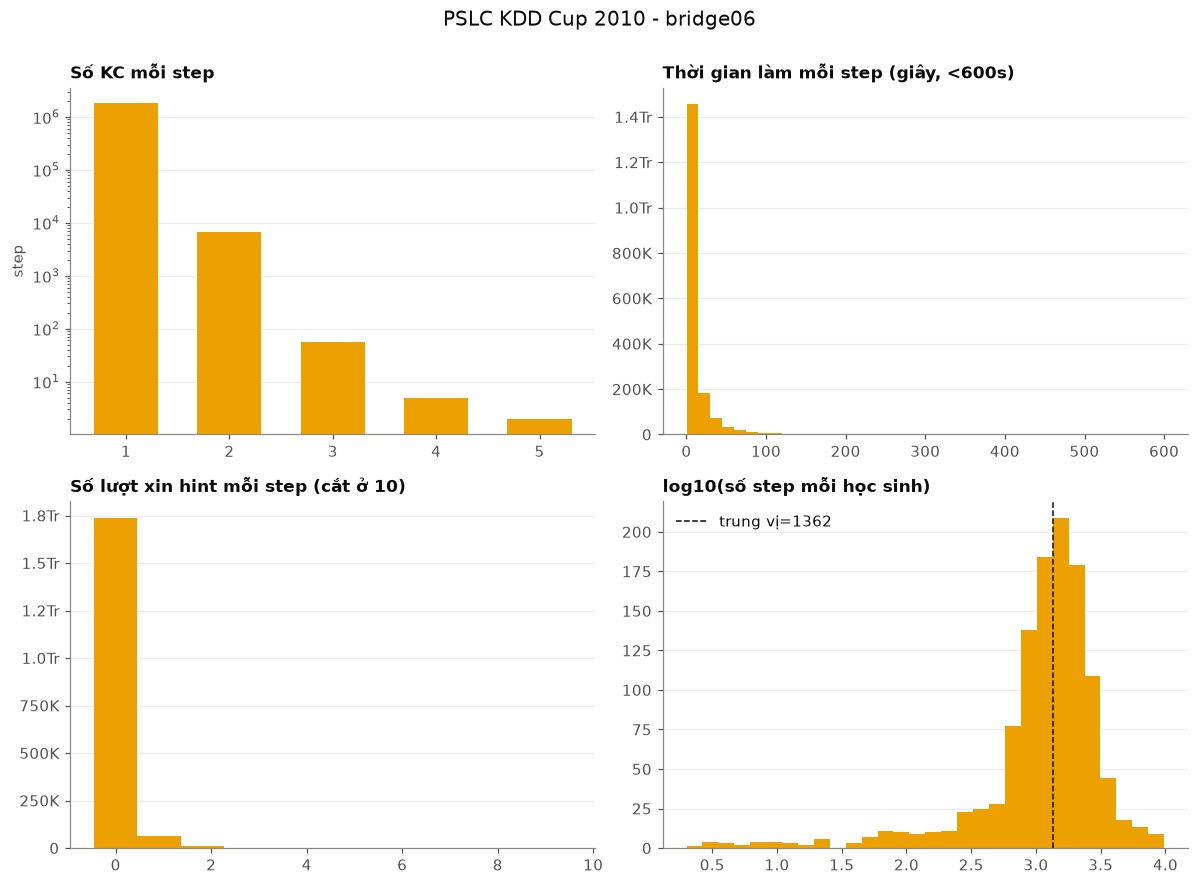

In [77]:
plot_kdd_dataset(brg, nkc_brg, seq_len_brg, "bridge06")


## 6. XES3G5M

Khác hẳn 4 family trên: dữ liệu đã được **pre-sequenced** (mỗi dòng là toàn
bộ chuỗi tương tác của một học sinh, nối bằng dấu phẩy) chứ không phải log
dạng long-format, và mỗi câu hỏi có **nội dung tiếng Trung đầy đủ** (đề bài,
lời giải `analysis`, đáp án, có thể kèm ảnh) - family duy nhất mang nội dung
ngôn ngữ tự nhiên thực sự, không chỉ id.


### 6.1 Cấu trúc file

In [78]:
display(inv[inv.family == "dataset XES3G5M (Google Drive)"].reset_index(drop=True))
n_xes_images = len(list((DATASETS_DIR / "dataset XES3G5M (Google Drive)" / "XES3G5M" / "metadata" / "images").glob("*.png")))
print(f"+ thư mục metadata/images/: {n_xes_images} file .png (đặt tên 'question_<id>-image_<n>.png' hoặc 'analysis_<id>-image_<n>.png')")


,family,file,kích thước
0,dataset XES3G5M (Google Drive),XES3G5M/kc_level/test.csv,41MB
1,dataset XES3G5M (Google Drive),XES3G5M/kc_level/test_question_window_sequence...,5GB
2,dataset XES3G5M (Google Drive),XES3G5M/kc_level/train_valid_sequences.csv,166MB
3,dataset XES3G5M (Google Drive),XES3G5M/metadata/embeddings/cid2content_emb.json,18MB
4,dataset XES3G5M (Google Drive),XES3G5M/metadata/embeddings/qid2analysis_emb.json,118MB
5,dataset XES3G5M (Google Drive),XES3G5M/metadata/embeddings/qid2content_emb.json,118MB
6,dataset XES3G5M (Google Drive),XES3G5M/metadata/kc_routes_map.json,58KB
7,dataset XES3G5M (Google Drive),XES3G5M/metadata/questions.json,7MB
8,dataset XES3G5M (Google Drive),XES3G5M/question_level/test_quelevel.csv,26MB
9,dataset XES3G5M (Google Drive),XES3G5M/question_level/test_window_sequences_q...,2GB


+ thư mục metadata/images/: 3869 file .png (đặt tên 'question_<id>-image_<n>.png' hoặc 'analysis_<id>-image_<n>.png')


In [79]:
XES_DIR = DATASETS_DIR / "dataset XES3G5M (Google Drive)" / "XES3G5M"
QL, KCL = XES_DIR / "question_level", XES_DIR / "kc_level"

_, _ = file_schema(QL / "train_valid_sequences_quelevel.csv", title="question_level/train_valid_sequences_quelevel.csv")



[question_level/train_valid_sequences_quelevel.csv]  30,965 dòng x 7 cột  (145.9 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,fold,Int64,30965,100.0%
1,uid,Int64,30965,100.0%
2,questions,String,30965,100.0%
3,concepts,String,30965,100.0%
4,responses,String,30965,100.0%
5,timestamps,String,30965,100.0%
6,selectmasks,String,30965,100.0%


Vài dòng dữ liệu mẫu:


fold,uid,questions,concepts,responses,timestamps,selectmasks
i64,i64,str,str,str,str,str
0,11066,"""3751,3752,3753,3754,1990,3739,…","""187,187,374,187,374,188,188,22…","""1,1,1,0,1,1,1,1,0,0,1,1,1,1,1,…","""1595229836000,1595233013000,15…","""1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…"
0,11066,"""1927,2125,2127,2128,2130,2129,…","""468,78,78,78,78,78,78,378,378,…","""1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,…","""1611827809000,1611829702000,16…","""1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…"
0,14482,"""266,268,2203,870,2316,2587,232…","""9,139,140,9,496,232,231,231,14…","""0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,…","""1595896054000,1595896054000,15…","""1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…"


In [80]:
_, _ = file_schema(KCL / "train_valid_sequences.csv", title="kc_level/train_valid_sequences.csv")



[kc_level/train_valid_sequences.csv]  33,397 dòng x 8 cột  (173.6 MB)


,cột,kiểu dữ liệu,dòng có dữ liệu,tỉ lệ có dữ liệu
0,fold,Int64,33397,100.0%
1,uid,Int64,33397,100.0%
2,questions,String,33397,100.0%
3,concepts,String,33397,100.0%
4,responses,String,33397,100.0%
5,timestamps,String,33397,100.0%
6,selectmasks,String,33397,100.0%
7,is_repeat,String,33397,100.0%


Vài dòng dữ liệu mẫu:


fold,uid,questions,concepts,responses,timestamps,selectmasks,is_repeat
i64,i64,str,str,str,str,str,str
0,11066,"""3751,3752,3753,3754,1990,3739,…","""187,187,374,187,374,188,188,22…","""1,1,1,0,1,1,1,1,0,0,0,1,1,1,1,…","""1595229836000,1595233013000,15…","""1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…","""0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…"
0,11066,"""95,4294,4294,4300,4300,4301,43…","""63,64,102,659,376,147,147,65,6…","""0,1,1,1,1,1,0,0,1,1,0,1,1,1,1,…","""1608890160000,1608892236000,16…","""1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…","""0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,…"
0,14482,"""266,268,2203,870,2316,2587,232…","""9,139,140,9,496,232,231,231,14…","""0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,…","""1595896054000,1595896054000,15…","""1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,…","""0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,…"


**Liên kết:** `question_level` và `kc_level` là **hai biểu diễn của cùng
dữ liệu thô ở 2 độ chi tiết khác nhau**, không phải 2 dataset độc lập - cùng
`uid`, cùng id câu hỏi, nhưng `kc_level` đã **tách sẵn** mỗi câu hỏi đa-KC
thành nhiều bước liên tiếp (nên cột `concepts` ở đây không còn ký tự nối `_`
nào). Id trong cột `questions` của cả 2 file trỏ vào khoá (dạng chuỗi) trong
`metadata/questions.json`; id trong cột `concepts` trỏ vào khoá trong
`metadata/kc_routes_map.json`. Ảnh trong `metadata/images/` minh hoạ cho đúng
`question_id` xuất hiện trong tên file.


### 6.2 Phân tích & trực quan hóa

In [81]:
# Đọc 1 file XES3G5M dạng pre-sequenced (mỗi dòng là cả chuỗi tương tác nối
# bằng dấu phẩy) và "nổ" (explode) các cột danh sách thành long-format
# (1 dòng = 1 tương tác), rồi chỉ giữ các dòng có nhãn đúng/sai hợp lệ.
def explode_xes(path: Path, cols) -> pl.DataFrame:
    df = pl.read_csv(path, columns=cols, schema_overrides={"uid": pl.Int64})
    list_cols = [c for c in cols if c not in ("fold", "uid")]
    df = df.with_columns([pl.col(c).str.split(",") for c in list_cols]).explode(list_cols)
    return df.filter(pl.col("responses").is_in(["0", "1"]))

xes = pl.concat([
    explode_xes(QL / "train_valid_sequences_quelevel.csv", ["fold", "uid", "questions", "concepts", "responses"]),
    explode_xes(QL / "test_quelevel.csv", ["fold", "uid", "questions", "concepts", "responses"]),
])
n_xes = xes.shape[0]
n_users_xes, n_q_xes = xes["uid"].n_unique(), xes["questions"].n_unique()
concepts_split = xes["concepts"].str.split("_")   # "_" = nhiều KC trên CÙNG 1 câu hỏi (question_level)
n_kc_xes = concepts_split.explode().n_unique()
pct_multi_xes = (concepts_split.list.len() > 1).mean()
acc_xes = (xes["responses"] == "1").mean()
seq_len_xes = xes.group_by("uid").len()["len"]
print(f"[question_level] tương tác: {n_xes:,} | học sinh: {n_users_xes:,} | câu hỏi: {n_q_xes:,} | "
      f"KC (concepts): {n_kc_xes} | tương tác đa-KC: {pct_multi_xes:.1%} | tỉ lệ đúng: {acc_xes:.1%}")

xes_kc = pl.concat([
    explode_xes(KCL / "train_valid_sequences.csv", ["fold", "uid", "questions", "concepts", "responses", "is_repeat"]),
    explode_xes(KCL / "test.csv", ["fold", "uid", "questions", "concepts", "responses", "is_repeat"]),
])
is_repeat_rate = (xes_kc["is_repeat"] == "1").mean()
print(f"[kc_level] số step (đã tách multi-KC): {xes_kc.shape[0]:,} | "
      f"tỉ lệ step luyện lại (is_repeat=1): {is_repeat_rate:.1%}")

SUMMARY["xes3g5m"] = dict(
    family="XES3G5M", n_interactions=n_xes, n_students=n_users_xes, n_questions=n_q_xes, n_kcs=n_kc_xes,
    pct_multi_kc=float(pct_multi_xes), correct_rate=float(acc_xes), median_seq_len=float(seq_len_xes.median()),
    has_timestamp=True, has_hint=False, has_affect=False, has_multimedia=True,
    file_format="CSV, list pre-sequenced", language="Tiếng Trung",
)

with open(XES_DIR / "metadata" / "questions.json") as f:
    qjson = json.load(f)
with open(XES_DIR / "metadata" / "kc_routes_map.json") as f:
    kc_routes_map = json.load(f)

types = pd.Series([v["type"] for v in qjson.values()]).value_counts()
route_depth = pd.Series([len(v["kc_routes"][0].split("----")) if v["kc_routes"] else 0 for v in qjson.values()])
n_routes_per_q = pd.Series([len(v["kc_routes"]) for v in qjson.values()])
analysis_len = pd.Series([len(v.get("analysis") or "") for v in qjson.values()])
img_files = list((XES_DIR / "metadata" / "images").glob("*.png"))
q_ids_with_image = {int(re.match(r"(question|analysis)_(\d+)-", p.name).group(2)) for p in img_files
                     if re.match(r"(question|analysis)_(\d+)-", p.name)}
pct_with_image = len(q_ids_with_image & set(int(k) for k in qjson.keys())) / len(qjson)
print(f"loại câu hỏi: {dict(types)} | cây KC: {len(kc_routes_map)} khái niệm, độ sâu phổ biến nhất {route_depth.mode()[0]} cấp")
print(f"câu hỏi có ≥1 ảnh (đề bài hoặc lời giải): {pct_with_image:.1%} | "
      f"có lời giải (analysis) ở {(analysis_len>0).mean():.1%} câu hỏi")


[question_level] tương tác: 5,549,184 | học sinh: 18,066 | câu hỏi: 7,651 | KC (concepts): 865 | tương tác đa-KC: 12.5% | tỉ lệ đúng: 79.5%
[kc_level] số step (đã tách multi-KC): 6,413,353 | tỉ lệ step luyện lại (is_repeat=1): 13.5%
loại câu hỏi: {'填空': np.int64(6142), '单选': np.int64(1510)} | cây KC: 1175 khái niệm, độ sâu phổ biến nhất 5 cấp
câu hỏi có ≥1 ảnh (đề bài hoặc lời giải): 35.8% | có lời giải (analysis) ở 100.0% câu hỏi


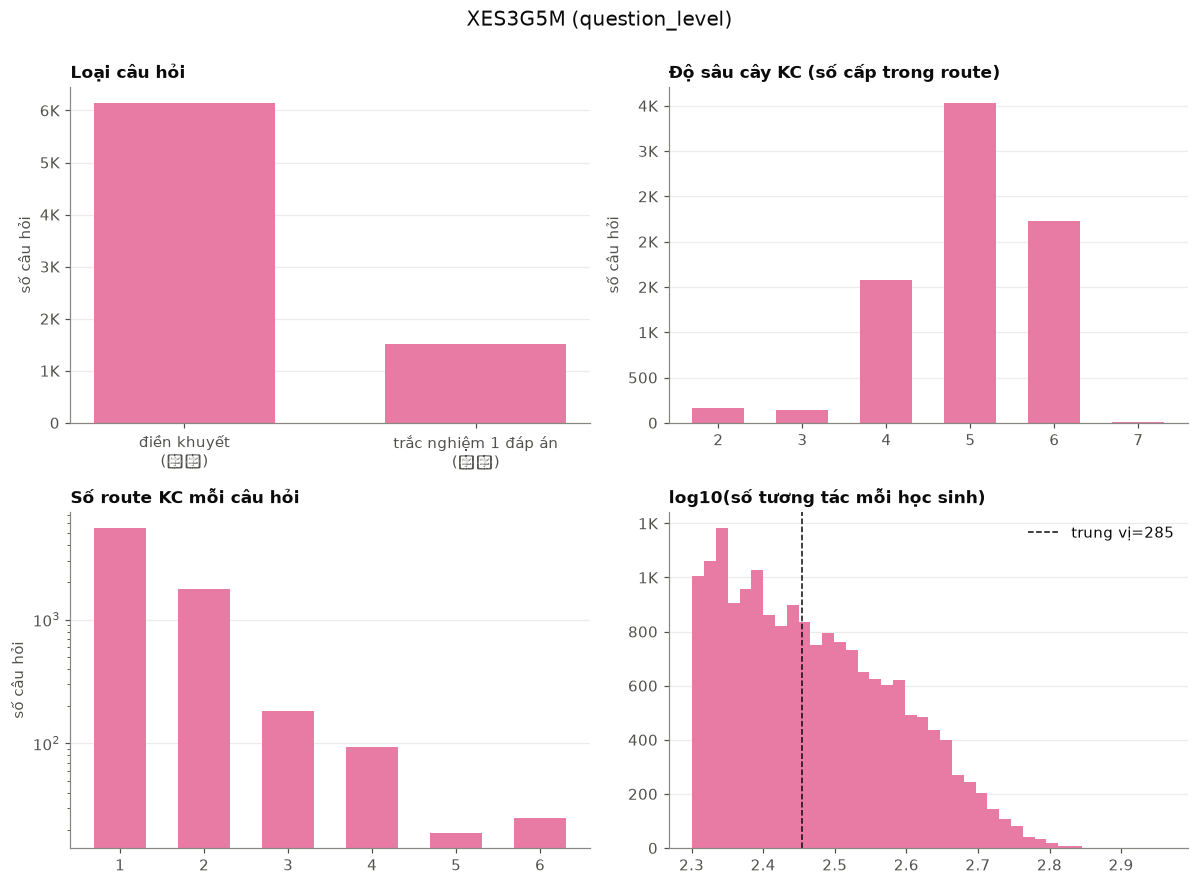

In [82]:
# hình gộp DUY NHẤT cho xes3g5m: 2 hàng x 2 cột
TYPE_VN = {"填空": "điền khuyết\n(填空)", "单选": "trắc nghiệm 1 đáp án\n(单选)"}  # font mặc định matplotlib không có glyph CJK
seq_len_xes_np = seq_len_xes.to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
bar(axes[0,0], [TYPE_VN.get(t, t) for t in types.index], list(types.values), DATASET_COLORS["xes3g5m"], "Loại câu hỏi", "số câu hỏi")
bar(axes[0,1], [str(i) for i in sorted(route_depth.value_counts().index)],
    [route_depth.value_counts()[i] for i in sorted(route_depth.value_counts().index)],
    DATASET_COLORS["xes3g5m"], "Độ sâu cây KC (số cấp trong route)", "số câu hỏi")
bar(axes[1,0], [str(i) for i in sorted(n_routes_per_q.value_counts().index)][:6],
    [n_routes_per_q.value_counts()[i] for i in sorted(n_routes_per_q.value_counts().index)][:6],
    DATASET_COLORS["xes3g5m"], "Số route KC mỗi câu hỏi", "số câu hỏi", ylog=True)
axes[1,1].hist(np.log10(seq_len_xes_np), bins=40, color=DATASET_COLORS["xes3g5m"])
axes[1,1].axvline(np.log10(np.median(seq_len_xes_np)), color=INK, ls="--", lw=1, label=f"trung vị={np.median(seq_len_xes_np):.0f}")
axes[1,1].legend(frameon=False)
axes[1,1].set_title("log10(số tương tác mỗi học sinh)", loc="left"); style_ax(axes[1,1])

fig.suptitle("XES3G5M (question_level)", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()


## 7. So sánh chéo 7 config

Từ đây trở đi mọi biểu đồ dùng **cùng một palette cố định** (`DATASET_COLORS`)
và cùng thứ tự (`DATASET_ORDER`) - một màu luôn ứng với đúng một dataset ở
mọi hình, không tô lại theo bối cảnh.


In [83]:
summary_df = pd.DataFrame(SUMMARY).T.loc[DATASET_ORDER]
summary_df.index.name = "dataset"
summary_df


,family,n_interactions,n_students,n_questions,n_kcs,pct_multi_kc,correct_rate,median_seq_len,has_timestamp,has_hint,has_affect,has_multimedia,file_format,language
dataset,,,,,,,,,,,,,,
assist09,ASSISTments 09-10,283105,4163,17751,149,0.0,0.658137,20.0,False,True,False,False,"CSV, dấu phẩy",Tiếng Anh
assist12,ASSISTments 12-13,2711602,29018,53086,265,0.0,0.695407,36.0,False,True,True,False,"CSV (nén zip), dấu phẩy",Tiếng Anh
algebra05,PSLC KDD Cup,607025,574,1084,112,0.313849,0.755288,574.5,True,True,False,False,"TXT, tab-separated",Tiếng Anh
bridge06,PSLC KDD Cup,1817476,1146,19005,493,0.00373,0.83215,1362.5,True,True,False,False,"TXT, tab-separated",Tiếng Anh
xes3g5m,XES3G5M,5549184,18066,7651,865,0.125181,0.79472,285.0,True,False,False,True,"CSV, list pre-sequenced",Tiếng Trung
eedi,Eedi NeurIPS'20,15867850,118971,27613,316,0.089052,0.64295,88.0,False,False,False,True,"CSV, dấu phẩy",Tiếng Anh
junyi,Junyi Academy,16217311,72758,25785,1326,0.0,0.703727,59.0,True,True,False,False,"CSV, dấu phẩy",Tiếng Trung (nội dung) / id ẩn danh (log)


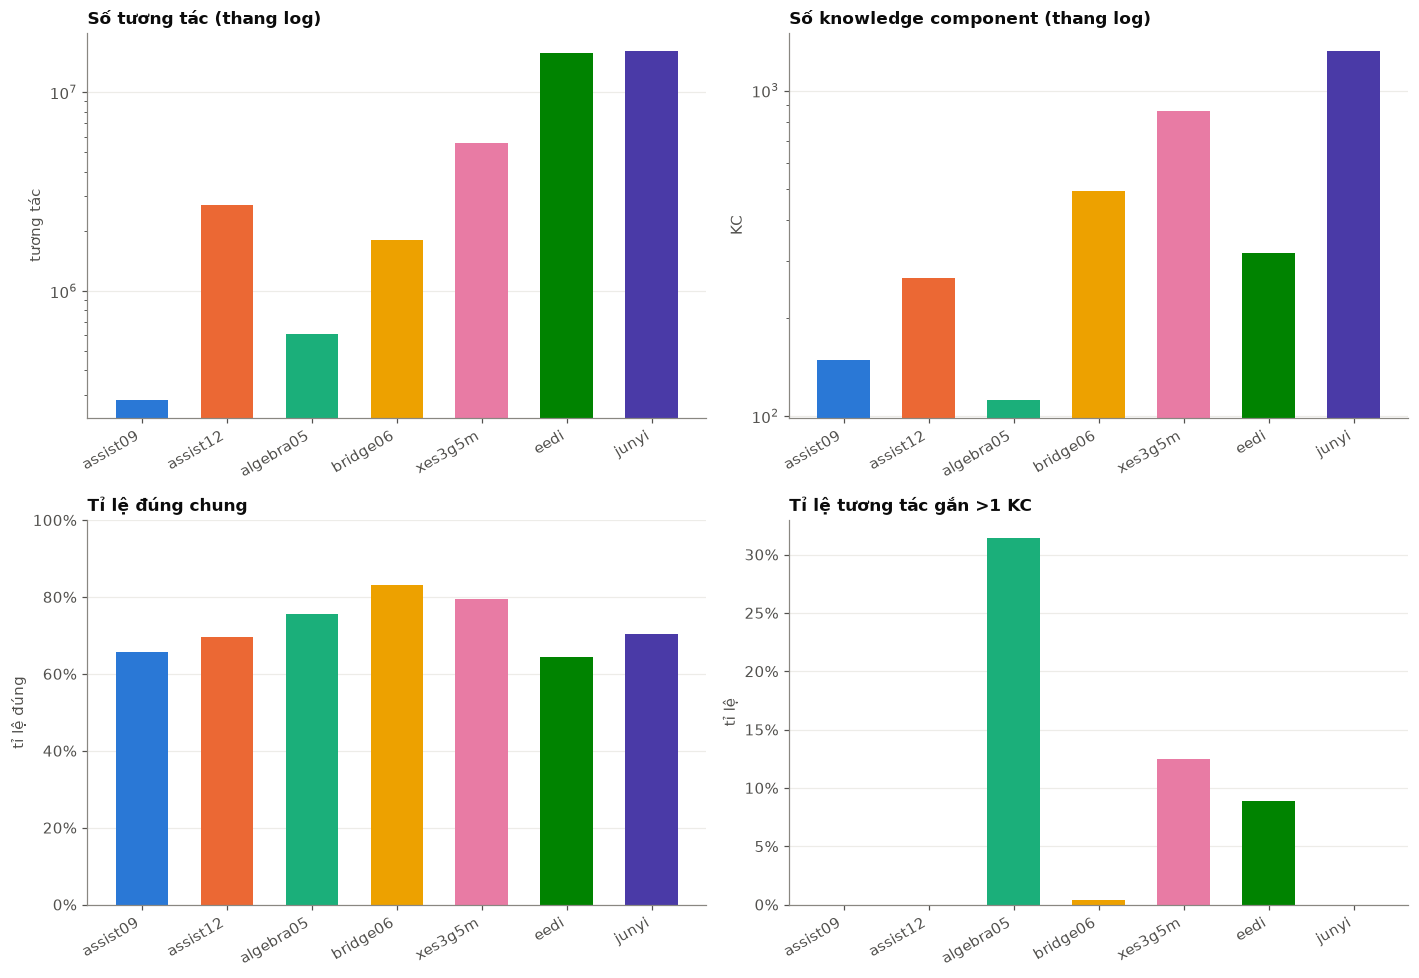

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = [DATASET_COLORS[d] for d in DATASET_ORDER]

bar(axes[0,0], DATASET_ORDER, summary_df["n_interactions"].astype(float), colors,
    "Số tương tác (thang log)", "tương tác", ylog=True, rot=30)
bar(axes[0,1], DATASET_ORDER, summary_df["n_kcs"].astype(float), colors,
    "Số knowledge component (thang log)", "KC", ylog=True, rot=30)
bar(axes[1,0], DATASET_ORDER, summary_df["correct_rate"].astype(float), colors,
    "Tỉ lệ đúng chung", "tỉ lệ đúng", rot=30, yfmt="pct")
axes[1,0].set_ylim(0, 1)
bar(axes[1,1], DATASET_ORDER, summary_df["pct_multi_kc"].astype(float), colors,
    "Tỉ lệ tương tác gắn >1 KC", "tỉ lệ", rot=30, yfmt="pct")

plt.tight_layout(); plt.show()


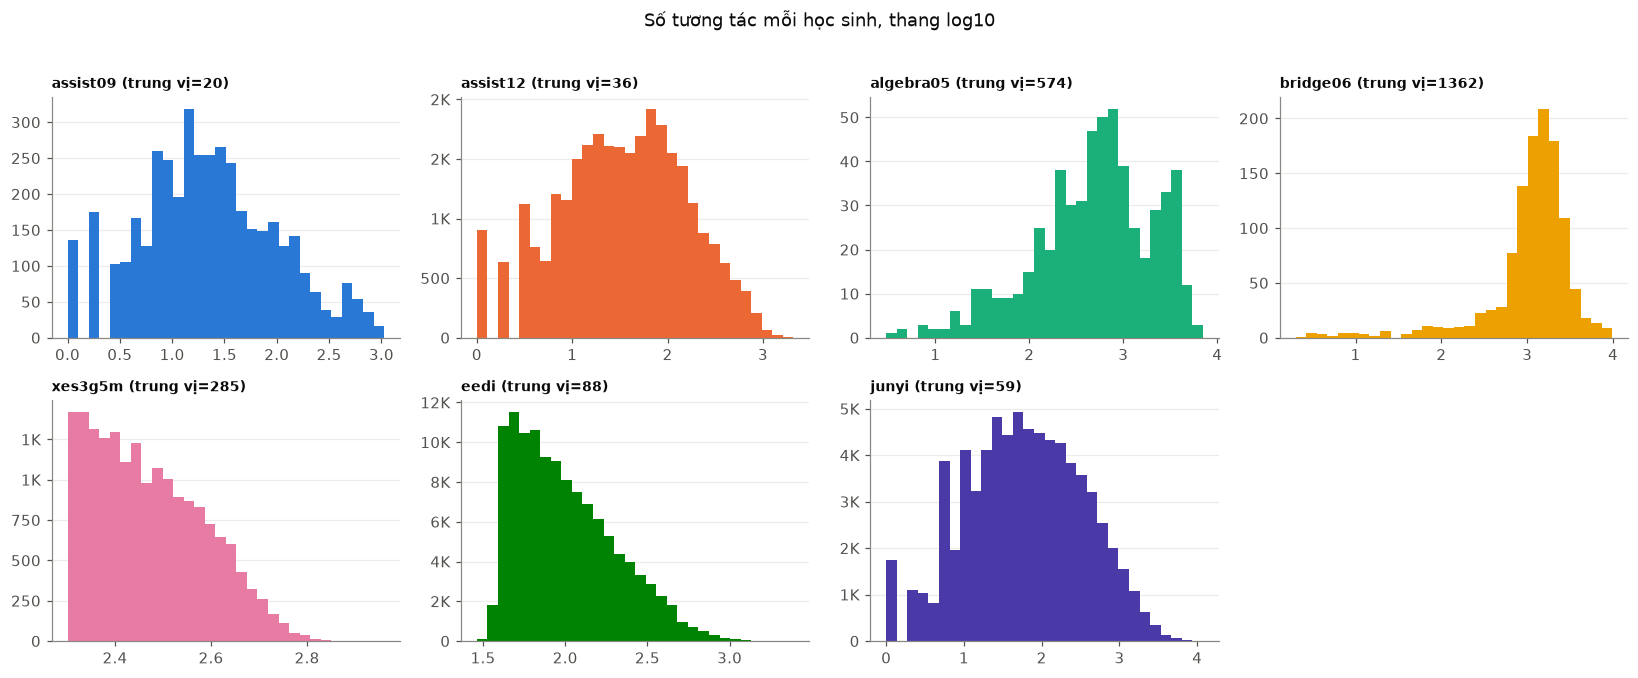

In [85]:
# small multiples (không gộp 7 màu vào 1 hình) cho phân phối độ dài chuỗi -
# mỗi ô giữ đúng màu cố định của dataset, tránh chồng lấn 7 màu khó đọc.
seq_data = {
    "assist09": seq_len09_np, "assist12": seq_len12_np, "eedi": seq_len_eedi_np,
    "junyi": seq_len_junyi_np, "algebra05": seq_len_alg.to_numpy(),
    "bridge06": seq_len_brg.to_numpy(), "xes3g5m": seq_len_xes_np,
}
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, ds in zip(axes.flat, DATASET_ORDER):
    v = seq_data[ds]
    ax.hist(np.log10(v[v > 0]), bins=30, color=DATASET_COLORS[ds])
    ax.set_title(f"{ds} (trung vị={int(np.median(v))})", loc="left", fontsize=9)
    style_ax(ax)
off(axes.flat[-1])
fig.suptitle("Số tương tác mỗi học sinh, thang log10", y=1.02)
plt.tight_layout(); plt.show()


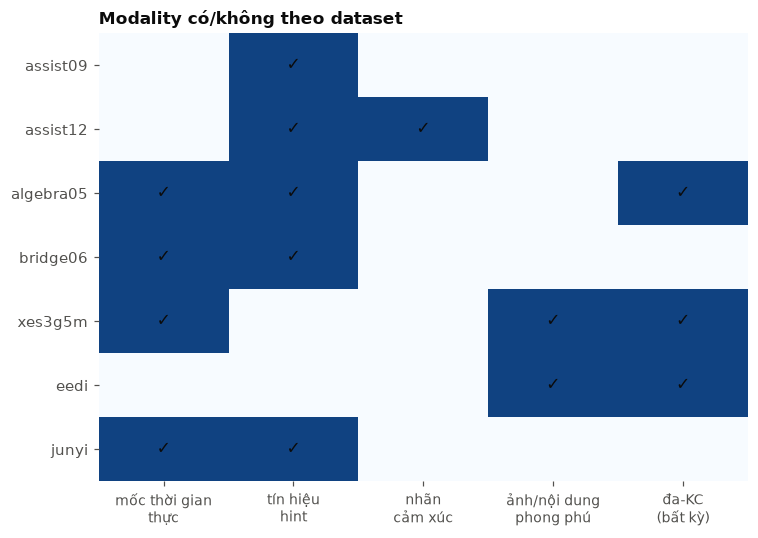

In [86]:
# ma trận hiện diện modality - đây là bài toán ĐỘ LỚN (có/không), nên dùng
# 1 hue tuần tự (xanh dương), không dùng rainbow.
feature_cols = ["has_timestamp", "has_hint", "has_affect", "has_multimedia", "pct_multi_kc"]
labels = ["mốc thời gian\nthực", "tín hiệu\nhint", "nhãn\ncảm xúc", "ảnh/nội dung\nphong phú", "đa-KC\n(bất kỳ)"]
mat = summary_df[feature_cols].copy()
mat["pct_multi_kc"] = (mat["pct_multi_kc"].astype(float) > 0.01)
mat = mat.astype(float).to_numpy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(mat, cmap=BLUE_CMAP, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(len(DATASET_ORDER))); ax.set_yticklabels(DATASET_ORDER)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, "✓" if mat[i,j] > 0.5 else "", ha="center", va="center", color=INK, fontsize=11)
ax.set_title("Modality có/không theo dataset", loc="left")
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()


## 8. Tổng hợp

**Cái giống nhau (đủ để chuẩn hoá thành một canonical schema `user, question,
kcs[], correct, ts`):** cả 7 config đều là log tương tác nhị phân đúng/sai
(hoặc suy ra được từ `Correct First Attempt`), đều gắn được với >=1 KC, đều
có đủ tín hiệu để suy ra thứ tự theo học sinh (timestamp thật hoặc id tăng
đơn điệu).

**Cái khác nhau - và tại sao nó quan trọng cho việc chọn config
(`code/configs/*.yaml`):**

- **Quy mô KC vocab** lệch 2 bậc độ lớn (`assist09` 149 skill vs `eedi`/
  `bridge06`/`xes3g5m` hàng nghìn) -> giải thích trực tiếp vì sao
  `bridge06`, `junyi`, `xes3g5m` được set `d_v: 16` (nhỏ hơn default 32) -
  KC space lớn hơn buộc phải giảm chiều value để giới hạn bộ nhớ mastery
  memory `M` (B, C, d_v).
- **Multi-KC per interaction** không đồng nhất: `assist09`, `eedi`,
  KDD Cup, và `xes3g5m` có một phần đáng kể interaction gắn nhiều KC (đòi hỏi
  `k_max` > 1 khi encode); `assist12` và `junyi` là single-KC tuyệt đối theo
  thiết kế file log.
- **Tín hiệu phụ đặc thù chưa được mô hình khai thác:** affect
  (frustrated/confused/concentrating/bored) chỉ có ở `assist12`; ảnh + lời
  giải tiếng Trung chỉ có ở `xes3g5m`; cờ downgrade/upgrade (độ khó thích
  ứng) chỉ có ở Junyi; hint/step-duration chi tiết chỉ có ở KDD Cup và
  ASSISTments. Hiện tại pipeline canonical hoá (`dpa_kt/data/loaders/`) bỏ
  hết các cột này để lấy chung `user, question, kcs, correct, ts` - đây là
  không gian mở rộng tự nhiên nếu muốn tận dụng thêm signal riêng của từng
  dataset.
- **Định dạng file** cũng khác: comma-CSV (ASSISTments, Eedi, Junyi,
  XES3G5M) vs tab-TXT (KDD Cup) vs pre-sequenced list-CSV (XES3G5M) vs
  zip-wrapped CSV (`assist12`) - lý do các loader trong `dpa_kt/data/loaders/`
  phải viết riêng cho từng family thay vì dùng một parser chung.


## 9. Dữ liệu phục vụ trình bày (PPTX)

Slide deck `phan_tich_datasets_kt.pptx` trích dẫn notebook này làm nguồn cho
mọi bảng/hình. Phần này chứa đúng đoạn code đã tạo ra 2 loại dữ liệu mà deck
dùng nhưng chưa có ở phần 2-8: **(9.1)** bảng "cột + vài dòng mẫu thật" cho
từng file thô, và **(9.2)** ví dụ sơ đồ nút quan hệ KC ↔ câu hỏi. Trước đây 2
phần này nằm ở 2 script riêng (`extract_file_samples.py`,
`extract_kc_graph_examples.py`) - nay gộp thẳng vào đây làm 1 nguồn duy nhất,
ghi ra `pptx_assets/*.json` để script dựng deck (`build_deck.js`) đọc lại.


### 9.1 Mẫu dữ liệu (cột + vài dòng thật) cho từng file

Dùng lại đúng cách đọc file (encoding/separator/schema_overrides) của phần
2-6 ở trên, để giá trị mẫu trùng khớp 100% với những gì notebook đã hiển thị.


In [87]:
# KHÔNG cắt ngắn - luôn trả về giá trị đầy đủ. Giữ tên hàm + tham số maxlen
# (không dùng) để không phải sửa các lời gọi truncate(...) phía dưới - yêu
# cầu là mọi giá trị hiển thị trong slide phải đầy đủ, không còn "..." cắt
# bớt ở bất kỳ đâu, kể cả dữ liệu mẫu.
def truncate(v, maxlen=42):
    if v is None:
        return ""
    return str(v)


# Dùng CHỈ cho cột kiểu pre-sequenced (cả 1 chuỗi tương tác của 1 học sinh nối
# bằng dấu phẩy, dài tới hàng nghìn ký tự - VD questions/concepts/responses/
# timestamps ở xes3g5m). Hiển thị ĐẦY ĐỦ 100% các cột này sẽ cần hàng chục
# dòng/slide cho MỖI cell, không đọc được. Thay vào đó: hiện head_n phần tử
# đầu + tổng số phần tử thực tế (không phải "..." mơ hồ mà có chú thích rõ
# còn bao nhiêu phần tử) - vẫn là dữ liệu THẬT, chỉ khác cách trình bày.
def preview_sequence(v, sep=",", head_n=5):
    if v is None:
        return ""
    s = str(v)
    parts = s.split(sep)
    if len(parts) <= head_n:
        return s
    return f"{sep.join(parts[:head_n])}, … (tổng {len(parts)} phần tử)"


# Đọc 1 file CSV thô và trả về cột + vài dòng mẫu THẬT (giữ đúng logic đọc -
# encoding/separator/schema_overrides - như các cell "Cấu trúc file" ở trên).
def sample_csv(path: Path, sep=",", encoding="utf8", schema_overrides=None, n=3, require_non_null=None,
                sequence_cols=None):
    # require_non_null: chọn dòng mẫu mà cột này CÓ dữ liệu, để 1 cột quan
    # trọng nhưng thưa (VD list_skill_ids, Confidence) không hiện rỗng ở cả 3
    # dòng mẫu chỉ vì tình cờ thứ tự dòng.
    # sequence_cols: tên các cột kiểu pre-sequenced (xem preview_sequence) -
    # CHỈ áp dụng preview có chú thích số lượng cho đúng các cột này, mọi cột
    # khác luôn hiển thị giá trị đầy đủ (không cắt).
    kwargs = dict(separator=sep, infer_schema_length=10000, ignore_errors=True,
                  schema_overrides=schema_overrides or {})
    if encoding != "utf8":
        df = pl.read_csv(path, encoding=encoding, **kwargs)
        names = df.columns
        dtypes = [str(t) for t in df.dtypes]
        if require_non_null:
            df = df.filter(pl.col(require_non_null).is_not_null())
        rows = df.head(n).rows()
    else:
        lf = pl.scan_csv(path, encoding=encoding, **kwargs)
        schema = lf.collect_schema()
        names = schema.names()
        dtypes = [str(schema[c]) for c in names]
        if require_non_null:
            lf = lf.filter(pl.col(require_non_null).is_not_null())
        rows = lf.head(n).collect().rows()
    seq_idx = {names.index(c) for c in (sequence_cols or []) if c in names}
    samples = [[preview_sequence(v) if i in seq_idx else truncate(v) for i, v in enumerate(r)] for r in rows]
    return {
        "columns": names, "dtypes": dtypes, "samples": samples, "size_bytes": path.stat().st_size,
    }


In [88]:
FILES = {}

# ---------------------------------------------------------------- assist09
FILES["assist09_skill_builder"] = dict(
    dataset="assist09", label="skill_builder_data_corrected.csv",
    data=sample_csv(ASSIST09_DIR / "skill_builder_data_corrected.csv", encoding="latin-1"),
)
FILES["assist09_non_skill_builder"] = dict(
    dataset="assist09", label="non_skill_builder_data_new.csv",
    data=sample_csv(ASSIST09_DIR / "non_skill_builder_data_new.csv", encoding="latin-1"),
)
FILES["assist09_full_log"] = dict(
    dataset="assist09", label="assistments_2009_2010.csv",
    data=sample_csv(ASSIST09_DIR / "assistments_2009_2010.csv", encoding="latin-1", require_non_null="list_skill_ids"),
)

# ---------------------------------------------------------------- assist12
# ASSIST12_RAW đã được giải nén ở mục 2.3 - dùng lại, không giải nén lần nữa.
FILES["assist12_full"] = dict(
    dataset="assist12", label="2012-2013-data-with-predictions-4-final.csv",
    data=sample_csv(ASSIST12_RAW, schema_overrides={"skill_id": pl.Utf8, "skill": pl.Utf8}),
)

# ---------------------------------------------------------------- eedi
FILES["eedi_train"] = dict(
    dataset="eedi", label="train_task_1_2.csv",
    data=sample_csv(EEDI_DIR / "train_data" / "train_task_1_2.csv"),
)
FILES["eedi_question_metadata"] = dict(
    dataset="eedi", label="question_metadata_task_1_2.csv",
    data=sample_csv(EEDI_DIR / "metadata" / "question_metadata_task_1_2.csv"),
)
FILES["eedi_subject_metadata"] = dict(
    dataset="eedi", label="subject_metadata.csv",
    data=sample_csv(EEDI_DIR / "metadata" / "subject_metadata.csv"),
)
FILES["eedi_student_metadata"] = dict(
    dataset="eedi", label="student_metadata_task_1_2.csv",
    data=sample_csv(EEDI_DIR / "metadata" / "student_metadata_task_1_2.csv"),
)
FILES["eedi_answer_metadata"] = dict(
    dataset="eedi", label="answer_metadata_task_1_2.csv",
    data=sample_csv(EEDI_DIR / "metadata" / "answer_metadata_task_1_2.csv", require_non_null="Confidence"),
)

# ---------------------------------------------------------------- junyi
FILES["junyi_log"] = dict(
    dataset="junyi", label="Log_Problem.csv",
    data=sample_csv(JUNYI_DIR / "Log_Problem.csv", schema_overrides={
        "is_correct": pl.Utf8, "uuid": pl.Utf8, "ucid": pl.Utf8, "upid": pl.Utf8},
        require_non_null="is_downgrade"),
)
FILES["junyi_userdata"] = dict(
    dataset="junyi", label="Info_UserData.csv",
    data=sample_csv(JUNYI_DIR / "Info_UserData.csv"),
)
FILES["junyi_content"] = dict(
    dataset="junyi", label="Info_Content.csv",
    data=sample_csv(JUNYI_DIR / "Info_Content.csv"),
)

# ---------------------------------------------------------------- PSLC KDD Cup
FILES["algebra05_train"] = dict(
    dataset="algebra05", label="algebra_2005_2006_train.txt",
    data=sample_csv(KDD_DIR / "algebra_2005_2006" / "algebra_2005_2006_train.txt", sep="\t",
                     schema_overrides={"Correct First Attempt": pl.Int64, "Step Duration (sec)": pl.Float64}),
)
FILES["bridge06_train"] = dict(
    dataset="bridge06", label="bridge_to_algebra_2006_2007_train.txt",
    data=sample_csv(KDD_DIR / "bridge_to_algebra_2006_2007" / "bridge_to_algebra_2006_2007_train.txt", sep="\t",
                     schema_overrides={"Correct First Attempt": pl.Int64, "Step Duration (sec)": pl.Float64}),
)

# ---------------------------------------------------------------- XES3G5M
FILES["xes_question_level"] = dict(
    dataset="xes3g5m", label="question_level/train_valid_sequences_quelevel.csv",
    data=sample_csv(XES_DIR / "question_level" / "train_valid_sequences_quelevel.csv", n=2,
                     sequence_cols=["questions", "concepts", "responses", "timestamps", "selectmasks"]),
)
FILES["xes_kc_level"] = dict(
    dataset="xes3g5m", label="kc_level/train_valid_sequences.csv",
    data=sample_csv(XES_DIR / "kc_level" / "train_valid_sequences.csv", n=2,
                     sequence_cols=["questions", "concepts", "responses", "timestamps", "selectmasks", "is_repeat"]),
)

with open(XES_DIR / "metadata" / "questions.json") as f:
    qjson_sample = json.load(f)
qkey = "1"  # 1 bản ghi ngắn, đại diện (index 0 là 1 bài toán đố dài)
qrec = qjson_sample[qkey]
FILES["xes_questions_json"] = dict(
    dataset="xes3g5m", label="metadata/questions.json",
    data={
        "columns": ["content", "kc_routes", "answer", "analysis", "type", "options"],
        "dtypes": ["str", "list[str]", "list[str]", "str", "str", "dict"],
        "samples": [[
            truncate(qrec.get("content"), 60),
            truncate(", ".join(qrec.get("kc_routes", [])), 60),
            truncate(", ".join(qrec.get("answer", [])), 60),
            truncate(qrec.get("analysis"), 60),
            qrec.get("type"),
            truncate(json.dumps(qrec.get("options"), ensure_ascii=False), 40),
        ]],
        "size_bytes": (XES_DIR / "metadata" / "questions.json").stat().st_size,
        "is_json": True, "record_key": f'"{qkey}"',
    },
)

with open(XES_DIR / "metadata" / "kc_routes_map.json") as f:
    kcmap = json.load(f)
FILES["xes_kc_routes_json"] = dict(
    dataset="xes3g5m", label="metadata/kc_routes_map.json",
    data={
        "columns": ["key (concept id)", "value (tên khái niệm)"],
        "dtypes": ["str", "str"],
        "samples": [[k, truncate(kcmap[k], 50)] for k in ["0", "1", "2"]],
        "size_bytes": (XES_DIR / "metadata" / "kc_routes_map.json").stat().st_size,
        "is_json": True,
    },
)

SAMPLES_OUT = ROOT / "pptx_assets" / "file_samples.json"
SAMPLES_OUT.parent.mkdir(parents=True, exist_ok=True)
with open(SAMPLES_OUT, "w") as f:
    json.dump(FILES, f, ensure_ascii=False, indent=1)
print(f"wrote {SAMPLES_OUT} ({len(FILES)} files)")
for k, v in FILES.items():
    print(f"  {k}: {len(v['data']['columns'])} cols")


wrote /home/admincsc/workspace/binh/openscience_kt_workspace/code/pptx_assets/file_samples.json (18 files)
  assist09_skill_builder: 31 cols
  assist09_non_skill_builder: 30 cols
  assist09_full_log: 20 cols
  assist12_full: 35 cols
  eedi_train: 6 cols
  eedi_question_metadata: 2 cols
  eedi_subject_metadata: 4 cols
  eedi_student_metadata: 4 cols
  eedi_answer_metadata: 6 cols
  junyi_log: 14 cols
  junyi_userdata: 12 cols
  junyi_content: 10 cols
  algebra05_train: 19 cols
  bridge06_train: 19 cols
  xes_question_level: 7 cols
  xes_kc_level: 8 cols
  xes_questions_json: 6 cols
  xes_kc_routes_json: 2 cols


### 9.2 Ví dụ sơ đồ KC ↔ câu hỏi

Logic hoàn toàn độc lập với `dpa_kt/data/kc_graph.py` (không dùng suy diễn
thống kê PMI/first-encounter của model cũ) - chỉ đọc trực tiếp quan hệ THẬT
có trong dữ liệu thô. Mỗi sơ đồ là 1 MẠNG nhiều-nhiều (không phải 1 thực thể
trung tâm), mỗi tầng cố gắng có >=3 thực thể thật khi dữ liệu cho phép:

- **`assist09`, `assist12`, `algebra05`, `bridge06`** (không có cây phân cấp
  KC sẵn) → kiểu `"network"`: nhiều KC thật, mỗi KC nối tới nhiều câu hỏi
  thật của riêng nó; nếu có multi-KC thật (1 câu hỏi cần nhiều KC), câu hỏi
  đó là 1 node dùng chung nối tới nhiều KC cùng lúc.
- **`eedi`, `junyi`, `xes3g5m`** (CÓ cây phân cấp KC sẵn trong metadata thô)
  → kiểu `"tree"`: mỗi cấp hiển thị khái niệm đang theo CÙNG các khái niệm
  "anh em" thật cùng cha, không chỉ 1 nhánh đơn độc; cấp cuối nối xuống
  nhiều câu hỏi thật.


In [89]:
# Dựng 1 mạng KC<->câu hỏi nhiều-nhiều THẬT từ danh sách KC hạt giống + map
# KC -> câu hỏi thật của nó (xem docstring bên trong để biết chi tiết).
def build_network(seed_kcs, kc_to_questions, shared_question=None, shared_kcs=None,
                   max_kcs=4, own_q_per_kc=3):
    """Dựng 1 mạng KC<->câu hỏi nhiều-nhiều THẬT. seed_kcs: các KC muốn hiển
    thị (ưu tiên các KC có trong 1 câu hỏi multi-KC thật, nếu có); mỗi KC sau
    đó được nối thêm tới các câu hỏi THẬT của riêng nó (kc_to_questions) để
    mỗi KC có nhiều hơn 1 cạnh, không chỉ dựa vào 1 câu hỏi dùng chung."""
    kcs = list(dict.fromkeys(seed_kcs))[:max_kcs]
    questions, edges = [], []
    shared_index = None
    if shared_question is not None:
        questions.append(shared_question)
        shared_index = 0
        for kc in shared_kcs or []:
            if kc in kcs:
                edges.append([kcs.index(kc), 0])
    for ki, kc in enumerate(kcs):
        added = 0
        for q in kc_to_questions.get(kc, []):
            if q == shared_question:
                continue
            if q in questions:
                qi = questions.index(q)
            else:
                questions.append(q)
                qi = len(questions) - 1
            edges.append([ki, qi])
            added += 1
            if added >= own_q_per_kc:
                break
    return {"type": "network", "kcs": kcs, "questions": questions, "edges": edges, "sharedIndex": shared_index}


KC_GRAPH = {}


In [90]:
# assist09 - skill_builder_data_corrected.csv là single-skill (đã kiểm chứng
# ở 2.2: 0% multi-skill) -> quan hệ fan-in của từng KC lấy từ đây; quan hệ
# multi-KC thật (1 câu hỏi cần nhiều KC) lấy từ assistments_2009_2010.csv
# (list_skill_ids nối bằng ";", có thật).
sb_kc = pl.read_csv(
    ASSIST09_DIR / "skill_builder_data_corrected.csv", encoding="latin-1", ignore_errors=True,
    columns=["problem_id", "skill_id", "skill_name"],
    schema_overrides={"skill_id": pl.Utf8, "skill_name": pl.Utf8},
).filter(
    pl.col("skill_id").is_not_null() & (pl.col("skill_id") != "")
    & pl.col("skill_name").is_not_null() & (pl.col("skill_name") != "")
)
kc_to_q_a9 = {
    r["skill_name"]: [str(q) for q in r["qs"]]
    for r in sb_kc.group_by("skill_name").agg(pl.col("problem_id").unique().alias("qs")).iter_rows(named=True)
}
full09_kc = pl.read_csv(
    ASSIST09_DIR / "assistments_2009_2010.csv", encoding="latin-1", ignore_errors=True,
    columns=["problem_id", "list_skill_ids", "list_skills"],
).filter(pl.col("list_skill_ids").str.contains(";"))
full09_kc = full09_kc.with_columns(pl.col("list_skills").str.split(";").list.len().alias("_n"))
r1 = full09_kc.sort("_n", descending=True).row(0, named=True)
a9_shared_kcs = [s.strip() for s in r1["list_skills"].split(";")]
KC_GRAPH["assist09"] = build_network(
    seed_kcs=a9_shared_kcs, kc_to_questions=kc_to_q_a9,
    shared_question=str(r1["problem_id"]), shared_kcs=a9_shared_kcs,
)
print("assist09:", KC_GRAPH["assist09"])


assist09: {'type': 'network', 'kcs': ['Conversion of Fraction Decimals Percents', 'Divisibility', 'Estimation', 'Multiplication and Division Integers'], 'questions': ['43963', '61100', '84787', '84744', '80430', '80376', '80658', '90543', '90594', '90425'], 'edges': [[0, 0], [1, 0], [2, 0], [3, 0], [0, 1], [0, 2], [0, 3], [2, 4], [2, 5], [2, 6], [3, 7], [3, 8], [3, 9]], 'sharedIndex': 0}


In [91]:
# assist12 - single-KC theo thiết kế log (đã kiểm chứng ở 2.4) -> không có
# multi-KC thật -> mạng chỉ gồm nhiều KC phổ biến, mỗi KC nối tới nhiều câu
# hỏi thật của riêng nó (không có node câu hỏi dùng chung).
a12_kc = pl.scan_csv(
    ASSIST12_RAW, infer_schema_length=10000, ignore_errors=True,
    schema_overrides={"skill_id": pl.Utf8, "skill": pl.Utf8},
).select(["problem_id", "skill_id", "skill"]).filter(
    pl.col("skill_id").is_not_null() & (pl.col("skill_id") != "")
    & pl.col("skill").is_not_null() & (pl.col("skill") != "")
).collect(engine="streaming")
fanin12_kc = (
    a12_kc.group_by("skill").agg(pl.col("problem_id").unique().alias("qs"))
    .filter(pl.col("qs").list.len() >= 3).sort(pl.col("qs").list.len(), descending=True)
)
top_kcs_12 = fanin12_kc["skill"].to_list()[:4]
kc_to_q_12 = {r["skill"]: [str(q) for q in r["qs"]] for r in fanin12_kc.iter_rows(named=True) if r["skill"] in top_kcs_12}
KC_GRAPH["assist12"] = build_network(seed_kcs=top_kcs_12, kc_to_questions=kc_to_q_12, own_q_per_kc=4)
print("assist12:", KC_GRAPH["assist12"])


assist12: {'type': 'network', 'kcs': ['Addition and Subtraction Fractions', 'Equation Solving Two or Fewer Steps', 'Unit Conversion Within a System', 'Addition and Subtraction Integers'], 'questions': ['86648', '86359', '86319', '186646', '87699', '88297', '94696', '97539', '124206', '124226', '124150', '357', '89896', '89905', '53896', '189224'], 'edges': [[0, 0], [0, 1], [0, 2], [0, 3], [1, 4], [1, 5], [1, 6], [1, 7], [2, 8], [2, 9], [2, 10], [2, 11], [3, 12], [3, 13], [3, 14], [3, 15]], 'sharedIndex': None}


In [92]:
# algebra05 / bridge06 - KC(Default)/KC(SubSkills) nối nhiều KC bằng "~~" khi
# 1 step cần >1 kỹ năng - đây là multi-KC THẬT, đọc trực tiếp không suy diễn.
# Mỗi KC trong đó cũng được nối thêm các step đơn-KC thật của riêng nó.
def kdd_network(train_txt: Path, kc_col: str) -> dict:
    df = pl.read_csv(
        train_txt, separator="\t", columns=["Step Name", "Problem Name", kc_col], ignore_errors=True,
    ).filter(pl.col(kc_col).is_not_null() & (pl.col(kc_col) != ""))
    multi = df.filter(pl.col(kc_col).str.contains("~~"))
    multi = multi.with_columns(pl.col(kc_col).str.split("~~").list.len().alias("_n"))
    r = multi.sort("_n", descending=True).row(0, named=True)
    shared_kcs = r[kc_col].split("~~")
    shared_q = r["Problem Name"] + " / " + r["Step Name"]

    # "Step Name" một mình KHÔNG duy nhất toàn cục (VD "FinalAnswer" lặp lại ở
    # hàng nghìn bài khác nhau) - ghép với "Problem Name" mới ra 1 bước học
    # thật sự khác nhau, giống định dạng dùng cho shared_q ở trên.
    single = df.filter(~pl.col(kc_col).str.contains("~~"))
    single = single.with_columns((pl.col("Problem Name") + " / " + pl.col("Step Name")).alias("step_key"))
    kc_to_q = {
        row[kc_col]: [str(s) for s in row["steps"]]
        for row in single.group_by(kc_col).agg(pl.col("step_key").unique().alias("steps")).iter_rows(named=True)
    }
    return build_network(seed_kcs=shared_kcs, kc_to_questions=kc_to_q, shared_question=shared_q, shared_kcs=shared_kcs)


KC_GRAPH["algebra05"] = kdd_network(KDD_DIR / "algebra_2005_2006" / "algebra_2005_2006_train.txt", "KC(Default)")
print("algebra05:", KC_GRAPH["algebra05"])
KC_GRAPH["bridge06"] = kdd_network(KDD_DIR / "bridge_to_algebra_2006_2007" / "bridge_to_algebra_2006_2007_train.txt", "KC(SubSkills)")
print("bridge06:", KC_GRAPH["bridge06"])


algebra05: {'type': 'network', 'kcs': ['distribute-sp', 'simplify-fractions-sp', 'combine-like-terms-sp', 'perform-mult-sp'], 'questions': ['LIT57A / FinalAnswer', 'EG56 / FinalAnswer', 'EG55 / FinalAnswer', 'EG55A / FinalAnswer', 'EG-EQS04-FIXED / FinalAnswer', 'EG-EQS06 / FinalAnswer', 'EG-EQS04 / FinalAnswer', 'EG40 / FinalAnswer', 'EG22 / FinalAnswer', 'EG-EPS04-FIXED / FinalAnswer', 'EG-EPS06 / FinalAnswer', 'EG-EPS05 / FinalAnswer'], 'edges': [[0, 0], [1, 0], [2, 0], [3, 0], [0, 1], [0, 2], [0, 3], [1, 4], [1, 5], [1, 6], [2, 7], [2, 1], [2, 8], [3, 9], [3, 10], [3, 11]], 'sharedIndex': 0}
bridge06: {'type': 'network', 'kcs': ['combine-like-terms-sp', 'perform-mult-row2-sp', 'simplify-fractions-sp', 'perform-mult-r-sp'], 'questions': ['Eg41 -10+9 = -9-y/9+9 / FinalAnswer', 'EG40A-CONSTANT 7 = -6y+(-6) / FinalAnswer', 'EG21A-CONSTANT 7+x = -7 / FinalAnswer', 'EG22 y+(-9) = 7 / FinalAnswer', 'EG74-CONSTANT -9*3 / FinalAnswer', 'EG72 2*11 / FinalAnswer', 'EG75 -4*(-4) / FinalAnswer'

In [93]:
# eedi - subject_metadata.csv có cây phân cấp CÓ SẴN (SubjectId -> ParentId).
# Ở MỖI cấp của 1 nhánh thật (gốc -> lá), hiển thị node đó CÙNG các anh em
# thật (cùng ParentId) trong metadata thô - không chỉ 1 chuỗi đơn lẻ. Kèm
# nhiều câu hỏi THẬT gắn với đúng KC lá đó.
subj_kc = pl.read_csv(EEDI_DIR / "metadata" / "subject_metadata.csv")
subj_kc = subj_kc.with_columns(pl.col("ParentId").cast(pl.Utf8, strict=False))
eedi_parent = {str(r["SubjectId"]): (None if r["ParentId"] == "NULL" else r["ParentId"]) for r in subj_kc.iter_rows(named=True)}
eedi_name = {str(r["SubjectId"]): r["Name"] for r in subj_kc.iter_rows(named=True)}
eedi_level = {str(r["SubjectId"]): r["Level"] for r in subj_kc.iter_rows(named=True)}
children_of_eedi = defaultdict(list)
for sid, p in eedi_parent.items():
    if p is not None:
        children_of_eedi[p].append(sid)
parents_used = set(subj_kc["ParentId"].drop_nulls().to_list()) - {"NULL"}
is_leaf = {sid: sid not in parents_used for sid in eedi_parent}

qmeta_kc = pl.read_csv(EEDI_DIR / "metadata" / "question_metadata_task_1_2.csv")
leaf_qcount = {}
for r in qmeta_kc.iter_rows(named=True):
    for sid in [str(s) for s in ast.literal_eval(r["SubjectId"])]:
        if is_leaf.get(sid):
            leaf_qcount.setdefault(sid, []).append(r["QuestionId"])
best_leaf = max(
    (sid for sid in leaf_qcount if eedi_level.get(sid, 0) >= 2),
    key=lambda sid: len(leaf_qcount[sid]),
)
eedi_chain = []
cur = best_leaf
while cur is not None:
    eedi_chain.append(cur)
    cur = eedi_parent.get(cur)
eedi_chain.reverse()


# Lấy 1 khái niệm (node_id) CÙNG các "anh em" thật (cùng cha) trong metadata
# thô eedi, tối đa `cap` node, để 1 cấp của cây không chỉ có 1 nhánh đơn độc.
def sibling_level(node_id, children_of, cap=4):
    p = eedi_parent.get(node_id)
    sibs = [node_id] + [c for c in children_of.get(p, []) if c != node_id] if p is not None else [node_id]
    nodes = [{"id": sid, "name": eedi_name.get(sid, sid)} for sid in sibs[:cap]]
    return {"nodes": nodes, "selected": 0}


levels_eedi = [sibling_level(nid, children_of_eedi) for nid in eedi_chain]
KC_GRAPH["eedi"] = {
    "type": "tree", "levels": levels_eedi,
    "questions": [str(q) for q in leaf_qcount[best_leaf][:6]],
}
print("eedi:", KC_GRAPH["eedi"])


eedi: {'type': 'tree', 'levels': [{'nodes': [{'id': '3', 'name': 'Maths'}], 'selected': 0}, {'nodes': [{'id': '32', 'name': 'Number'}, {'id': '49', 'name': 'Algebra'}, {'id': '71', 'name': 'Geometry and Measure'}, {'id': '101', 'name': 'Data and Statistics'}], 'selected': 0}, {'nodes': [{'id': '144', 'name': 'Basic Arithmetic'}, {'id': '35', 'name': 'Calculator Use'}, {'id': '36', 'name': 'Decimals'}, {'id': '37', 'name': 'Factors, Multiples and Primes'}], 'selected': 0}, {'nodes': [{'id': '203', 'name': 'Mental Addition and Subtraction'}, {'id': '33', 'name': 'BIDMAS'}, {'id': '200', 'name': 'Counting'}, {'id': '202', 'name': 'Place Value'}], 'selected': 0}], 'questions': ['11968', '25942', '15263', '26896', '25378', '19637']}


In [94]:
# junyi - Info_Content.csv có cây phân cấp CÓ SẴN (level1_id..level4_id ->
# ucid). level1_id chỉ có 1 giá trị DUY NHẤT trong toàn bộ file (gốc thật sự
# chỉ có 1 node - không bịa thêm) -> chọn nhánh level2/3/4/ucid có nhiều
# "anh em" thật nhất (>=3 mỗi cấp) để minh hoạ đúng độ phân nhánh thật của dữ
# liệu, kèm nhiều upid THẬT (Log_Problem.csv) gắn với đúng ucid lá đó.
content_kc = pl.read_csv(JUNYI_DIR / "Info_Content.csv", ignore_errors=True)
content_kc = content_kc.filter(
    pl.col("level1_id").is_not_null() & pl.col("level4_id").is_not_null() & pl.col("content_pretty_name").is_not_null()
)
best = None
for l2 in content_kc["level2_id"].unique().to_list():
    sub2 = content_kc.filter(pl.col("level2_id") == l2)
    l3s = sub2["level3_id"].unique().to_list()
    for l3 in l3s:
        sub3 = sub2.filter(pl.col("level3_id") == l3)
        l4s = sub3["level4_id"].unique().to_list()
        for l4 in l4s:
            n_ucid = sub3.filter(pl.col("level4_id") == l4)["ucid"].n_unique()
            score = min(len(l3s), len(l4s), n_ucid)
            if best is None or score > best[0]:
                best = (score, l2, l3, l4)
_, best_l2, best_l3, best_l4 = best
crow = content_kc.filter(
    (pl.col("level2_id") == best_l2) & (pl.col("level3_id") == best_l3) & (pl.col("level4_id") == best_l4)
).row(0, named=True)
level1_all = content_kc["level1_id"].unique().to_list()
level2_all = content_kc.filter(pl.col("level1_id") == crow["level1_id"])["level2_id"].unique().to_list()
level3_all = content_kc.filter((pl.col("level1_id") == crow["level1_id"]) & (pl.col("level2_id") == crow["level2_id"]))["level3_id"].unique().to_list()
level4_all = content_kc.filter(
    (pl.col("level1_id") == crow["level1_id"]) & (pl.col("level2_id") == crow["level2_id"]) & (pl.col("level3_id") == crow["level3_id"])
)["level4_id"].unique().to_list()
ucid_rows = content_kc.filter(
    (pl.col("level1_id") == crow["level1_id"]) & (pl.col("level2_id") == crow["level2_id"])
    & (pl.col("level3_id") == crow["level3_id"]) & (pl.col("level4_id") == crow["level4_id"])
)[["ucid", "content_pretty_name"]].unique()
ucid_name = dict(zip(ucid_rows["ucid"].to_list(), ucid_rows["content_pretty_name"].to_list()))


# Cùng ý tưởng cho junyi: target CÙNG tối đa (cap-1) giá trị "anh em" thật
# khác lấy từ all_vals (danh sách giá trị thật cùng cấp, cùng tiền tố cha).
def pick_siblings(all_vals, target, cap=4):
    others = [v for v in all_vals if v != target]
    return [target] + others[: cap - 1]


levels_junyi = [
    {"nodes": [{"id": v, "name": None} for v in pick_siblings(level1_all, crow["level1_id"])], "selected": 0},
    {"nodes": [{"id": v, "name": None} for v in pick_siblings(level2_all, crow["level2_id"])], "selected": 0},
    {"nodes": [{"id": v, "name": None} for v in pick_siblings(level3_all, crow["level3_id"])], "selected": 0},
    {"nodes": [{"id": v, "name": None} for v in pick_siblings(level4_all, crow["level4_id"])], "selected": 0},
    {"nodes": [{"id": v, "name": ucid_name.get(v)} for v in pick_siblings(list(ucid_name.keys()), crow["ucid"])], "selected": 0},
]
lf_log_kc = pl.scan_csv(
    JUNYI_DIR / "Log_Problem.csv", infer_schema_length=10000, ignore_errors=True,
    schema_overrides={"uuid": pl.Utf8, "ucid": pl.Utf8, "upid": pl.Utf8},
).filter(pl.col("ucid") == crow["ucid"]).select("upid").unique().head(6).collect(engine="streaming")
KC_GRAPH["junyi"] = {
    "type": "tree", "levels": levels_junyi,
    "questions": [str(u) for u in lf_log_kc["upid"].to_list()],
}
print("junyi:", KC_GRAPH["junyi"])


junyi: {'type': 'tree', 'levels': [{'nodes': [{'id': 'aH0Dz0KdH9gio7rrcGRHvrmd9vcd/0WJbeEFB7qeUKA=', 'name': None}], 'selected': 0}, {'nodes': [{'id': '7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=', 'name': None}, {'id': '1EzKLzTq9Ax8/wlR9cJNrtthvk9lBi/SFdx/4L1PIaE=', 'name': None}, {'id': 'jXSXg7CfDboPEXlnqJTGuQOb0VIgOXCpaU/Sl+/m3n0=', 'name': None}, {'id': 'MfUX4BrIuFzJjm97tCQVisXbonyvtYtwCUJo6JpmoyU=', 'name': None}], 'selected': 0}, {'nodes': [{'id': 'scsWmkZsfmdmD2IzB24sQ1Au1BOXYgQEx9zO3+4glq8=', 'name': None}, {'id': 'a2w4FdOiBsy7t1fsstano3rtWKyay8qPhPd4U6Er7YQ=', 'name': None}, {'id': 'ItasYR+er/FlZlRvL66/NB3wY0AvmlrZKoqe4gmPyD0=', 'name': None}, {'id': '31v13N8GN4hIUpg1IsMv4DVkK8Hlb0XhHnHnBR1Ivcs=', 'name': None}], 'selected': 0}, {'nodes': [{'id': '3GvjX2SWIfgJ5amac6qRuK7kpl8vJGlnSecATUZeyys=', 'name': None}, {'id': 'hq6uCe9NmtCc+0wlbGGIsxegP2cqYAdFebGd+v4/o8Q=', 'name': None}, {'id': 'QveDXHYtspe3tNggjIr6cNoA1ghw4K5kmQT115hFzYI=', 'name': None}, {'id': 'TGo2lGzYTV/WNVrFuE6/+F

In [95]:
# xes3g5m - metadata/questions.json có "kc_routes" CÓ SẴN (chuỗi phân cấp
# khái niệm nối bằng "----") -> dựng tập hợp TẤT CẢ route thật, chọn 1 route
# 5 cấp có độ phân nhánh (số "anh em" thật cùng tiền tố) lớn nhất ở mọi cấp,
# rồi hiển thị các anh em thật đó ở từng cấp; kèm nhiều câu hỏi thật có đúng
# route đầy đủ này.
with open(XES_DIR / "metadata" / "questions.json") as f:
    qjson_kc = json.load(f)
all_routes = set()
route_qcount = {}
for v in qjson_kc.values():
    for r in v.get("kc_routes", []):
        t = tuple(r.split("----"))
        all_routes.add(t)
        route_qcount[t] = route_qcount.get(t, 0) + 1

root_sibs_global = {x[0] for x in all_routes}
# Trong các route 5 cấp có độ phân nhánh (số "anh em" thật) >= 3 ở MỌI cấp,
# ưu tiên route có nhiều câu hỏi thật gắn đúng route đầy đủ nhất - để cấp
# "câu hỏi" cuối cùng cũng có nhiều ví dụ, không chỉ riêng các cấp khái niệm.
cands = []
for r in all_routes:
    if len(r) != 5:
        continue
    counts = [len(root_sibs_global)]
    for d in range(1, len(r)):
        prefix = r[:d]
        sibs = {x[d] for x in all_routes if len(x) > d and x[: d] == prefix}
        counts.append(len(sibs))
    score = min(counts)
    if score >= 3:
        cands.append((route_qcount[r], score, r))
chain_xes = max(cands)[2] if cands else max(
    ((min([len(root_sibs_global)] + [len({x[d] for x in all_routes if len(x) > d and x[:d] == r[:d]}) for d in range(1, len(r))]), r)
     for r in all_routes if len(r) == 5)
)[1]


# Lấy các "anh em" thật ở đúng độ sâu depth của route đang theo (chain_xes),
# tức các concept khác cùng chung tiền tố route thật trong toàn bộ dữ liệu.
def xes_siblings(depth, cap=4):
    if depth == 0:
        sibs = {x[0] for x in all_routes}
    else:
        prefix = chain_xes[:depth]
        sibs = {x[depth] for x in all_routes if len(x) > depth and x[:depth] == prefix}
    target = chain_xes[depth]
    return [target] + [s for s in sibs if s != target][: cap - 1]


levels_xes = [{"nodes": [{"id": n, "name": n} for n in xes_siblings(d)], "selected": 0} for d in range(len(chain_xes))]
same_chain_keys = [k for k, v in qjson_kc.items() if v.get("kc_routes") and tuple(v["kc_routes"][0].split("----")) == chain_xes][:6]
KC_GRAPH["xes3g5m"] = {"type": "tree", "levels": levels_xes, "questions": same_chain_keys}
print("xes3g5m:", KC_GRAPH["xes3g5m"])


xes3g5m: {'type': 'tree', 'levels': [{'nodes': [{'id': '拓展思维', 'name': '拓展思维'}, {'id': '题型', 'name': '题型'}, {'id': '知识点', 'name': '知识点'}, {'id': '课内题型', 'name': '课内题型'}], 'selected': 0}, {'nodes': [{'id': '应用题模块', 'name': '应用题模块'}, {'id': '计算模块', 'name': '计算模块'}, {'id': '几何模块', 'name': '几何模块'}, {'id': '组合模块', 'name': '组合模块'}], 'selected': 0}, {'nodes': [{'id': '周期问题', 'name': '周期问题'}, {'id': '还原问题', 'name': '还原问题'}, {'id': '应用题模块排队问题', 'name': '应用题模块排队问题'}, {'id': '间隔问题', 'name': '间隔问题'}], 'selected': 0}, {'nodes': [{'id': '时间中的周期问题', 'name': '时间中的周期问题'}, {'id': '数列操作周期问题', 'name': '数列操作周期问题'}, {'id': '环形操作周期问题', 'name': '环形操作周期问题'}, {'id': '基本排列的周期问题', 'name': '基本排列的周期问题'}], 'selected': 0}, {'nodes': [{'id': '日期中的周期', 'name': '日期中的周期'}, {'id': '求某日期是周几问题', 'name': '求某日期是周几问题'}, {'id': '时间中的周期', 'name': '时间中的周期'}, {'id': '求再过几日是周几问题', 'name': '求再过几日是周几问题'}], 'selected': 0}], 'questions': ['81', '346', '349', '638', '639', '944']}


In [96]:
KC_GRAPH_OUT = ROOT / "pptx_assets" / "kc_graph_examples.json"
KC_GRAPH_OUT.parent.mkdir(parents=True, exist_ok=True)
with open(KC_GRAPH_OUT, "w", encoding="utf-8") as f:
    json.dump(KC_GRAPH, f, ensure_ascii=False, indent=1)
print(f"wrote {KC_GRAPH_OUT}")


wrote /home/admincsc/workspace/binh/openscience_kt_workspace/code/pptx_assets/kc_graph_examples.json
